## 6. Preprocessing Lanjutan: Drop Kolom dan One-Hot Encoding

Setelah EDA dan pengecekan keseimbangan kelas, lakukan preprocessing lanjutan:
- Drop kolom tidak relevan (`id_pelanggan`) dan kolom yang mengandung **data leakage** (`gagal_bayar_tercatat`)
- **One-Hot Encoding** untuk variabel kategorikal nominal (`status_pekerjaan`, `tipe_produk`, `tujuan_pinjaman`). *Penggunaan Label/Ordinal Encoding pada variabel nominal kurang tepat karena dapat membuat algoritma menangkap hubungan ordinal/urutan yang sebenarnya tidak ada. Teknik One-Hot Encoding mencegah bias urutan ini.*

## 1. Import Library yang Dibutuhkan

Import semua library yang diperlukan untuk analisis data, visualisasi, preprocessing, modeling, dan evaluasi.

In [ ]:
# ============================================
# Import Library
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Cross Validation + Hyperparameter Tuning
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Statistical Test
from scipy.stats import ttest_rel

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2. Load dan Eksplorasi Dataset

Load dataset pinjaman dan lakukan eksplorasi awal untuk memahami struktur data, tipe data, dan informasi umum dataset.

In [ ]:
# ============================================
# Load Dataset
# ============================================
df = pd.read_csv('data/loan_data.csv')

print("=" * 60)
print("INFORMASI UMUM DATASET")
print("=" * 60)
print(f"Jumlah Baris   : {df.shape[0]:,}")
print(f"Jumlah Kolom   : {df.shape[1]}")
print(f"Ukuran Dataset : {df.shape[0] * df.shape[1]:,} cells")
print("=" * 60)

# Tampilkan 5 baris pertama
print("\n📋 5 Baris Pertama Dataset:")
df.head()

INFORMASI UMUM DATASET
Jumlah Baris   : 50,000
Jumlah Kolom   : 20
Ukuran Dataset : 1,000,000 cells

📋 5 Baris Pertama Dataset:


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33.0,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42.0,Student,1.1,20840,689,8.4,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53.0,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32.0,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.92,0.195,1.565,0.522,1


In [ ]:
# Info detail dataset
print("📊 Informasi Detail Dataset:")
print("-" * 60)
df.info()

📊 Informasi Detail Dataset:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id_pelanggan                          50000 non-null  object 
 1   usia                                  49858 non-null  float64
 2   status_pekerjaan                      49842 non-null  object 
 3   lama_bekerja_tahun                    50000 non-null  float64
 4   pendapatan_tahunan                    50000 non-null  int64  
 5   skor_kredit                           50000 non-null  int64  
 6   lama_riwayat_kredit_tahun             50000 non-null  float64
 7   aset_tabungan                         50000 non-null  int64  
 8   hutang_saat_ini                       50000 non-null  int64  
 9   gagal_bayar_tercatat                  50000 non-null  int64 

In [ ]:
# Statistik deskriptif
print("📈 Statistik Deskriptif:")
print("-" * 60)
df.describe().round(2)

📈 Statistik Deskriptif:
------------------------------------------------------------


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
count,49858.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,34.96,7.45,50062.89,643.61,8.17,3595.62,14290.44,0.05,0.55,0.15,33041.87,15.50,0.29,0.70,0.23,0.55
std,11.12,7.61,32630.50,64.73,7.21,13232.40,13243.76,0.22,0.85,0.41,26116.19,4.07,0.16,0.47,0.16,0.50
min,18.00,0.00,15000.00,348.00,0.00,0.00,60.00,0.00,0.00,0.00,500.00,6.00,0.00,0.01,0.00,0.00
25%,26.00,1.30,27280.50,600.00,2.00,130.00,5581.00,0.00,0.00,0.00,12300.00,12.18,0.16,0.33,0.11,0.00
50%,35.00,4.90,41607.50,643.00,6.10,568.00,10385.00,0.00,0.00,0.00,26100.00,15.44,0.26,0.62,0.21,1.00
75%,43.00,11.40,62723.25,687.00,12.60,2271.00,18449.25,0.00,1.00,0.00,48500.00,18.87,0.39,1.01,0.34,1.00
max,70.00,39.90,250000.00,850.00,30.00,300000.00,163344.00,1.00,9.00,4.00,100000.00,23.00,0.80,2.00,0.67,1.00


## 3. Preprocessing Data: Handling Missing Values

Langkah preprocessing awal meliputi:
- Cek dan tangani missing values

> ⚠️ **Catatan:** Drop kolom tidak relevan dan Label Encoding dilakukan pada **Step 6** (setelah EDA), agar visualisasi kategorikal pada tahap EDA masih menggunakan label asli.


🔍 Pengecekan Missing Values:
                  Jumlah Missing  Persentase (%)
usia                         142            0.28
status_pekerjaan             158            0.32

Total kolom dengan missing values: 2


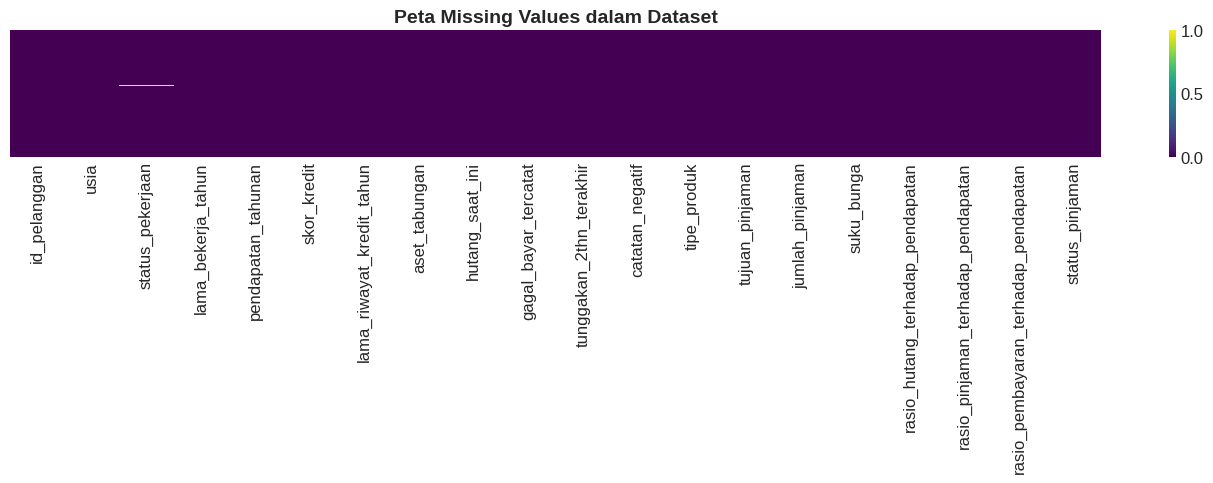

In [ ]:
# ============================================
# 3.1 Cek Missing Values
# ============================================
print("🔍 Pengecekan Missing Values:")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal kolom dengan missing values: {len(missing_df)}")
else:
    print("✅ Tidak ada missing values dalam dataset!")

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Peta Missing Values dalam Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 3.2 Handling Missing Values
# ============================================
print("🔧 Penanganan Missing Values:")
print("=" * 50)

# Cek jumlah sebelum
print(f"Jumlah baris sebelum penanganan: {len(df):,}")

# Kolom 'usia' (numerik) → isi dengan median
if df['usia'].isnull().sum() > 0:
    median_usia = df['usia'].median()
    df['usia'].fillna(median_usia, inplace=True)
    print(f"  - Kolom 'usia': {df['usia'].isnull().sum()} missing → diisi dengan median ({median_usia})")

# Kolom 'status_pekerjaan' (kategorikal) → isi dengan modus
if df['status_pekerjaan'].isnull().sum() > 0:
    modus_pekerjaan = df['status_pekerjaan'].mode()[0]
    df['status_pekerjaan'].fillna(modus_pekerjaan, inplace=True)
    print(f"  - Kolom 'status_pekerjaan': diisi dengan modus ('{modus_pekerjaan}')")

print(f"\nJumlah baris setelah penanganan: {len(df):,}")
print(f"Total missing values tersisa: {df.isnull().sum().sum()}")
print("✅ Missing values berhasil ditangani!")

🔧 Penanganan Missing Values:
Jumlah baris sebelum penanganan: 50,000
  - Kolom 'usia': 0 missing → diisi dengan median (35.0)
  - Kolom 'status_pekerjaan': diisi dengan modus ('Employed')

Jumlah baris setelah penanganan: 50,000
Total missing values tersisa: 0
✅ Missing values berhasil ditangani!


## 4. Exploratory Data Analysis (EDA)

Visualisasi dan analisis dilakukan **sebelum encoding** agar label kategorikal asli tetap terbaca dan interpretasi lebih mudah dipahami. Tahap EDA meliputi:
- Distribusi variabel target
- Distribusi fitur numerik dan kategorikal
- Korelasi antar fitur numerik
- Statistik deskriptif per kelas


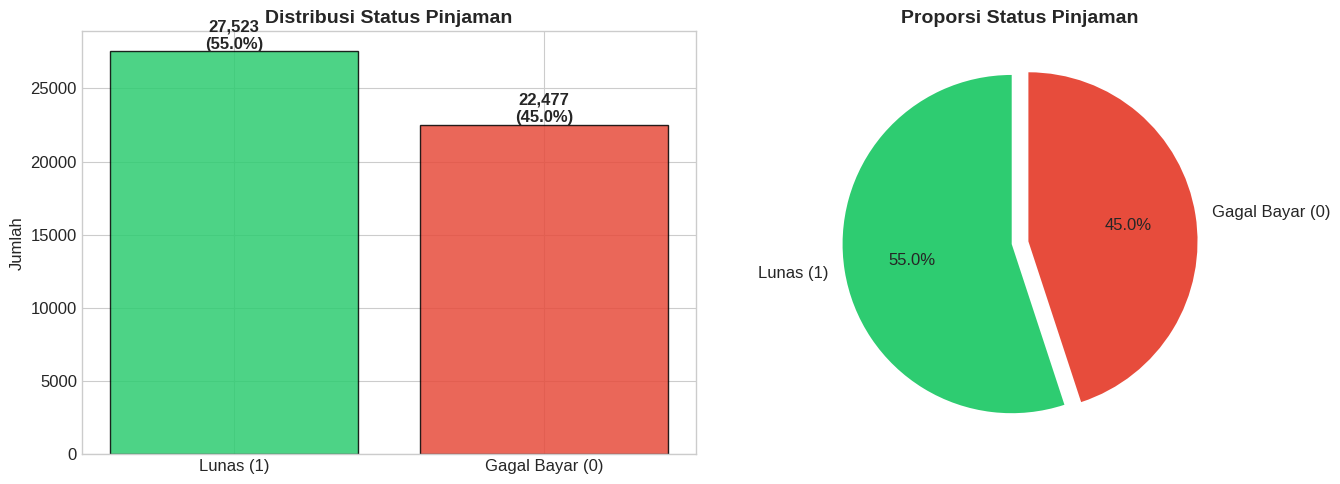


📊 Distribusi Target:
   Lunas (1)      : 27,523 (55.05%)
   Gagal Bayar (0): 22,477 (44.95%)


In [ ]:
# ============================================
# 4.1 Distribusi Variabel Target
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
target_counts = df['status_pinjaman'].value_counts()
labels = ['Lunas (1)', 'Gagal Bayar (0)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, [target_counts[1], target_counts[0]], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Status Pinjaman', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate([target_counts[1], target_counts[0]]):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[1], target_counts[0]], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Pinjaman', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Distribusi Target:")
print(f"   Lunas (1)      : {target_counts[1]:,} ({target_counts[1]/len(df)*100:.2f}%)")
print(f"   Gagal Bayar (0): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.2f}%)")


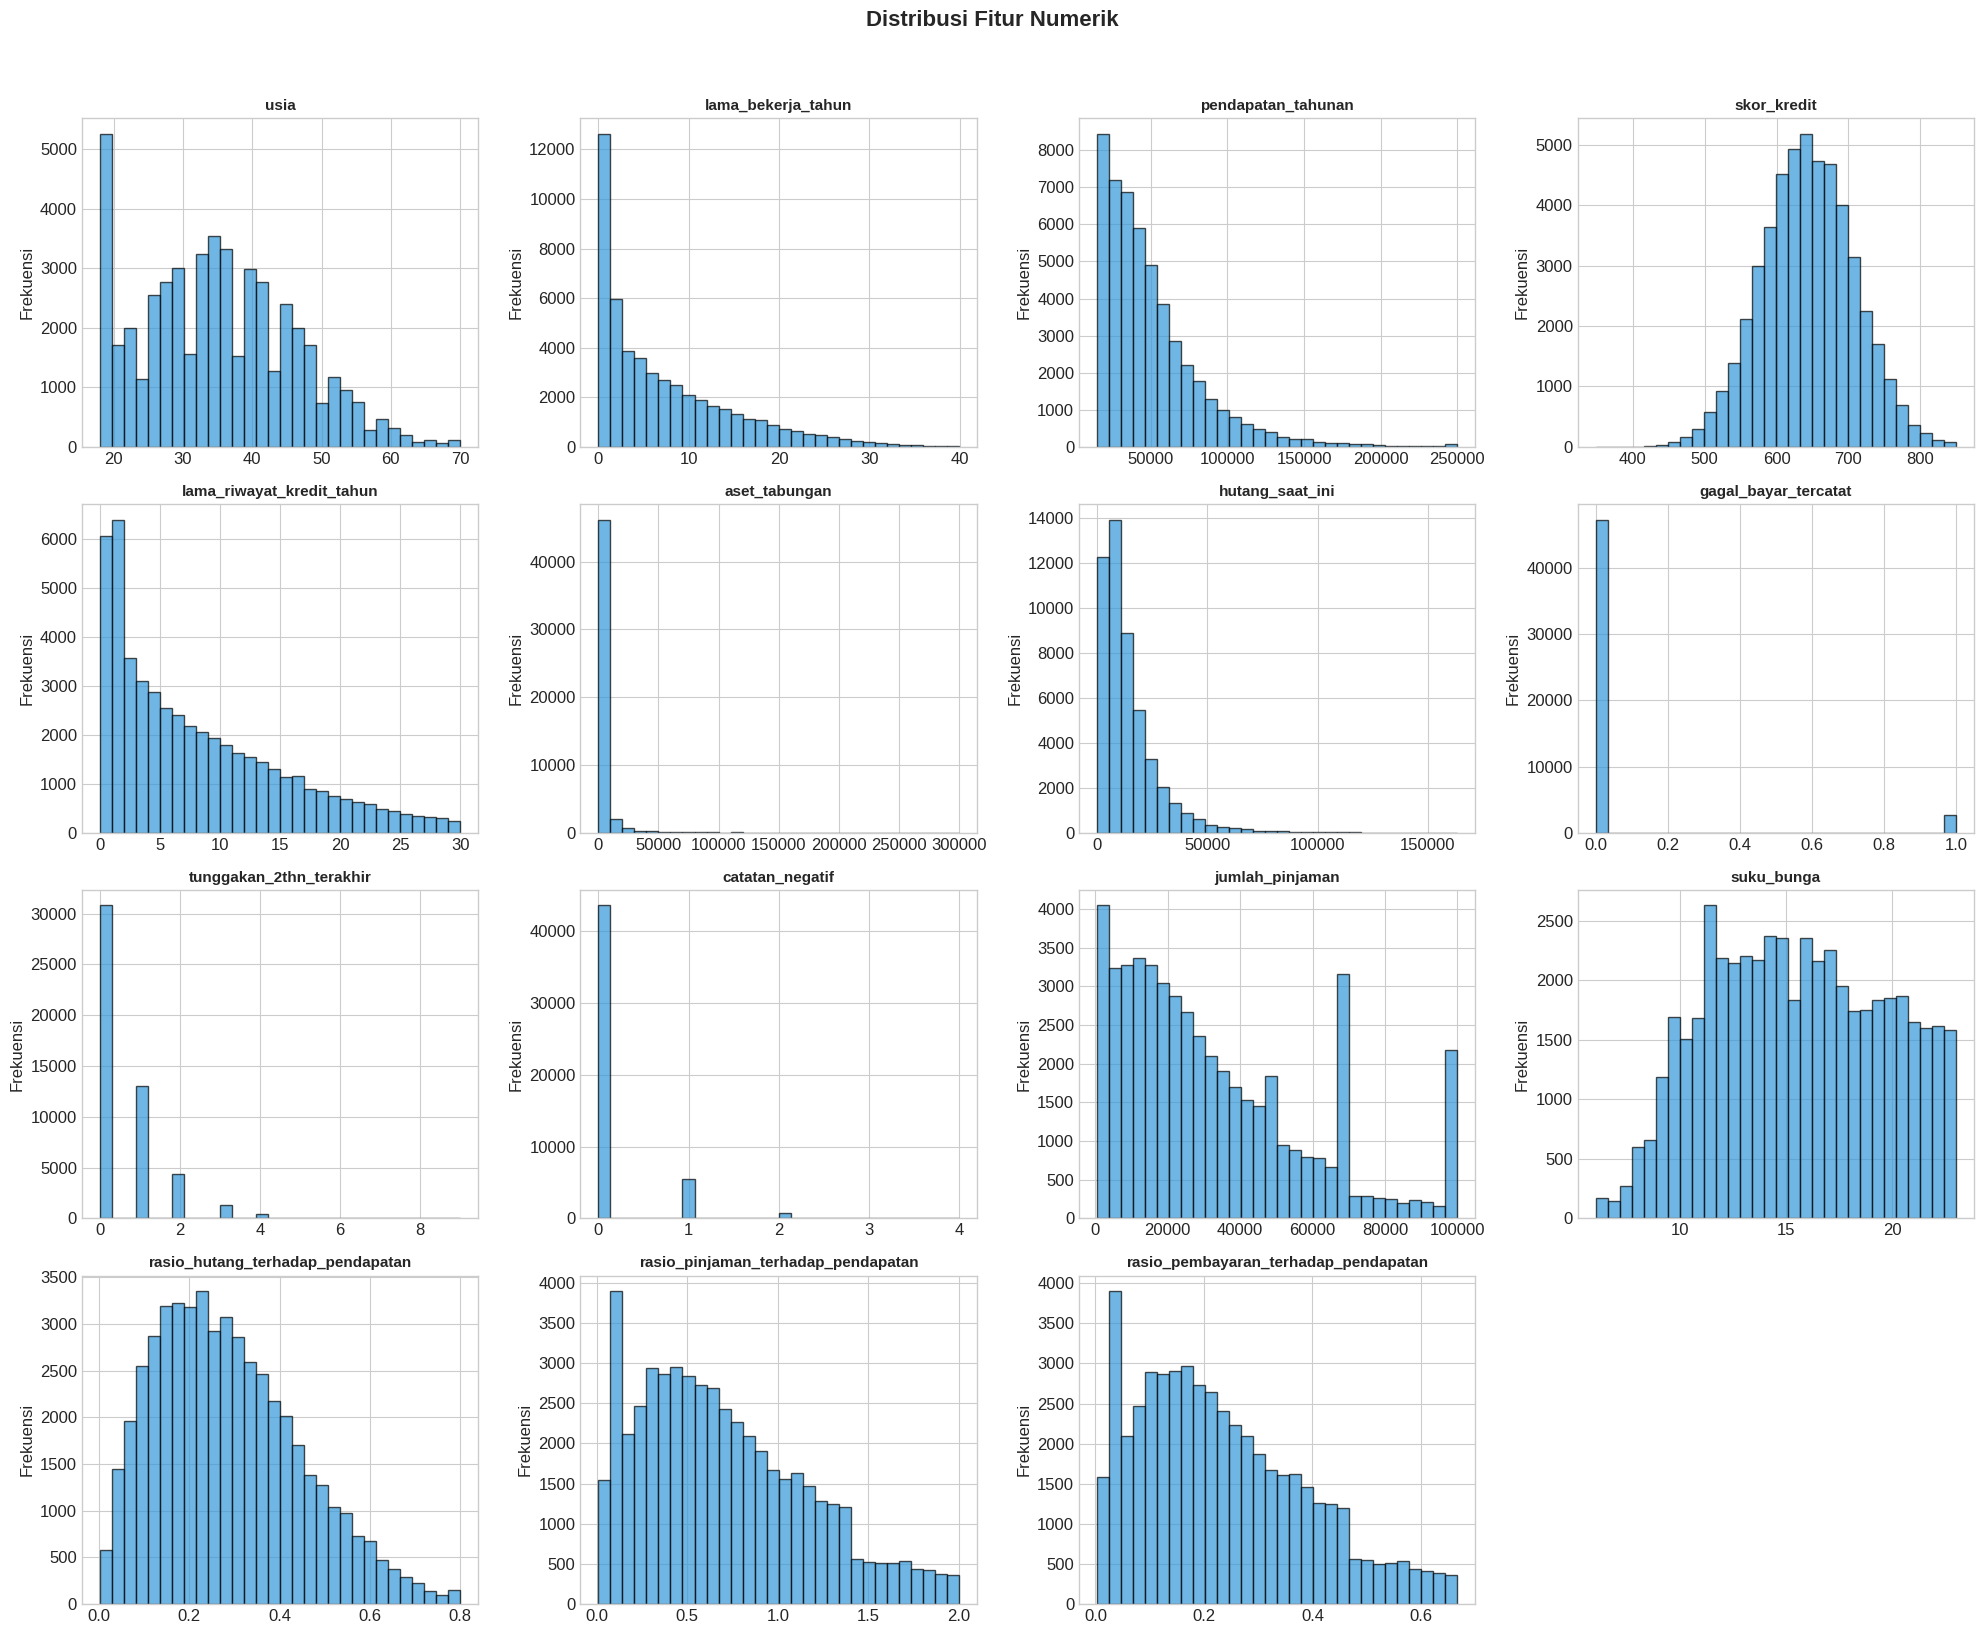

In [ ]:
# ============================================
# 4.2 Distribusi Fitur Numerik (Histogram)
# ============================================
num_cols = df.select_dtypes(include=[np.number]).columns.drop('status_pinjaman').tolist()

n_cols_plot = 4
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')

# Hapus axes kosong
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# 4.2b Distribusi Fitur Kategorikal (Bar Chart)
# ============================================
# cat_cols_eda = df.select_dtypes(include='object').columns.tolist()

# if cat_cols_eda:
#     n_cat = len(cat_cols_eda)
#     fig, axes = plt.subplots(1, n_cat, figsize=(6 * n_cat, 5))
#     if n_cat == 1:
#         axes = [axes]

#     for i, col in enumerate(cat_cols_eda):
#         vc = df[col].value_counts()
#         axes[i].bar(vc.index, vc.values, color='#9b59b6', edgecolor='black', alpha=0.85)
#         axes[i].set_title(col, fontsize=11, fontweight='bold')
#         axes[i].set_ylabel('Frekuensi')
#         axes[i].tick_params(axis='x', rotation=30)
#         for j, v in enumerate(vc.values):
#             axes[i].text(j, v + 50, f'{v:,}', ha='center', fontsize=9)

#     plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold', y=1.02)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Tidak ada fitur kategorikal dalam dataset.")


In [ ]:
# ============================================
# 4.3 Boxplot Fitur Numerik berdasarkan Kelas Target
# ============================================
# fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 4))
# axes = axes.flatten()

# for i, col in enumerate(num_cols):
#     sns.boxplot(x='status_pinjaman', y=col, data=df, ax=axes[i],
#                 palette=['#e74c3c', '#2ecc71'], order=[0, 1])
#     axes[i].set_title(col, fontsize=11, fontweight='bold')
#     axes[i].set_xticks([0, 1])
#     axes[i].set_xticklabels(['Gagal Bayar (0)', 'Lunas (1)'])

# for j in range(len(num_cols), len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle('Boxplot Fitur Numerik berdasarkan Status Pinjaman', fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()


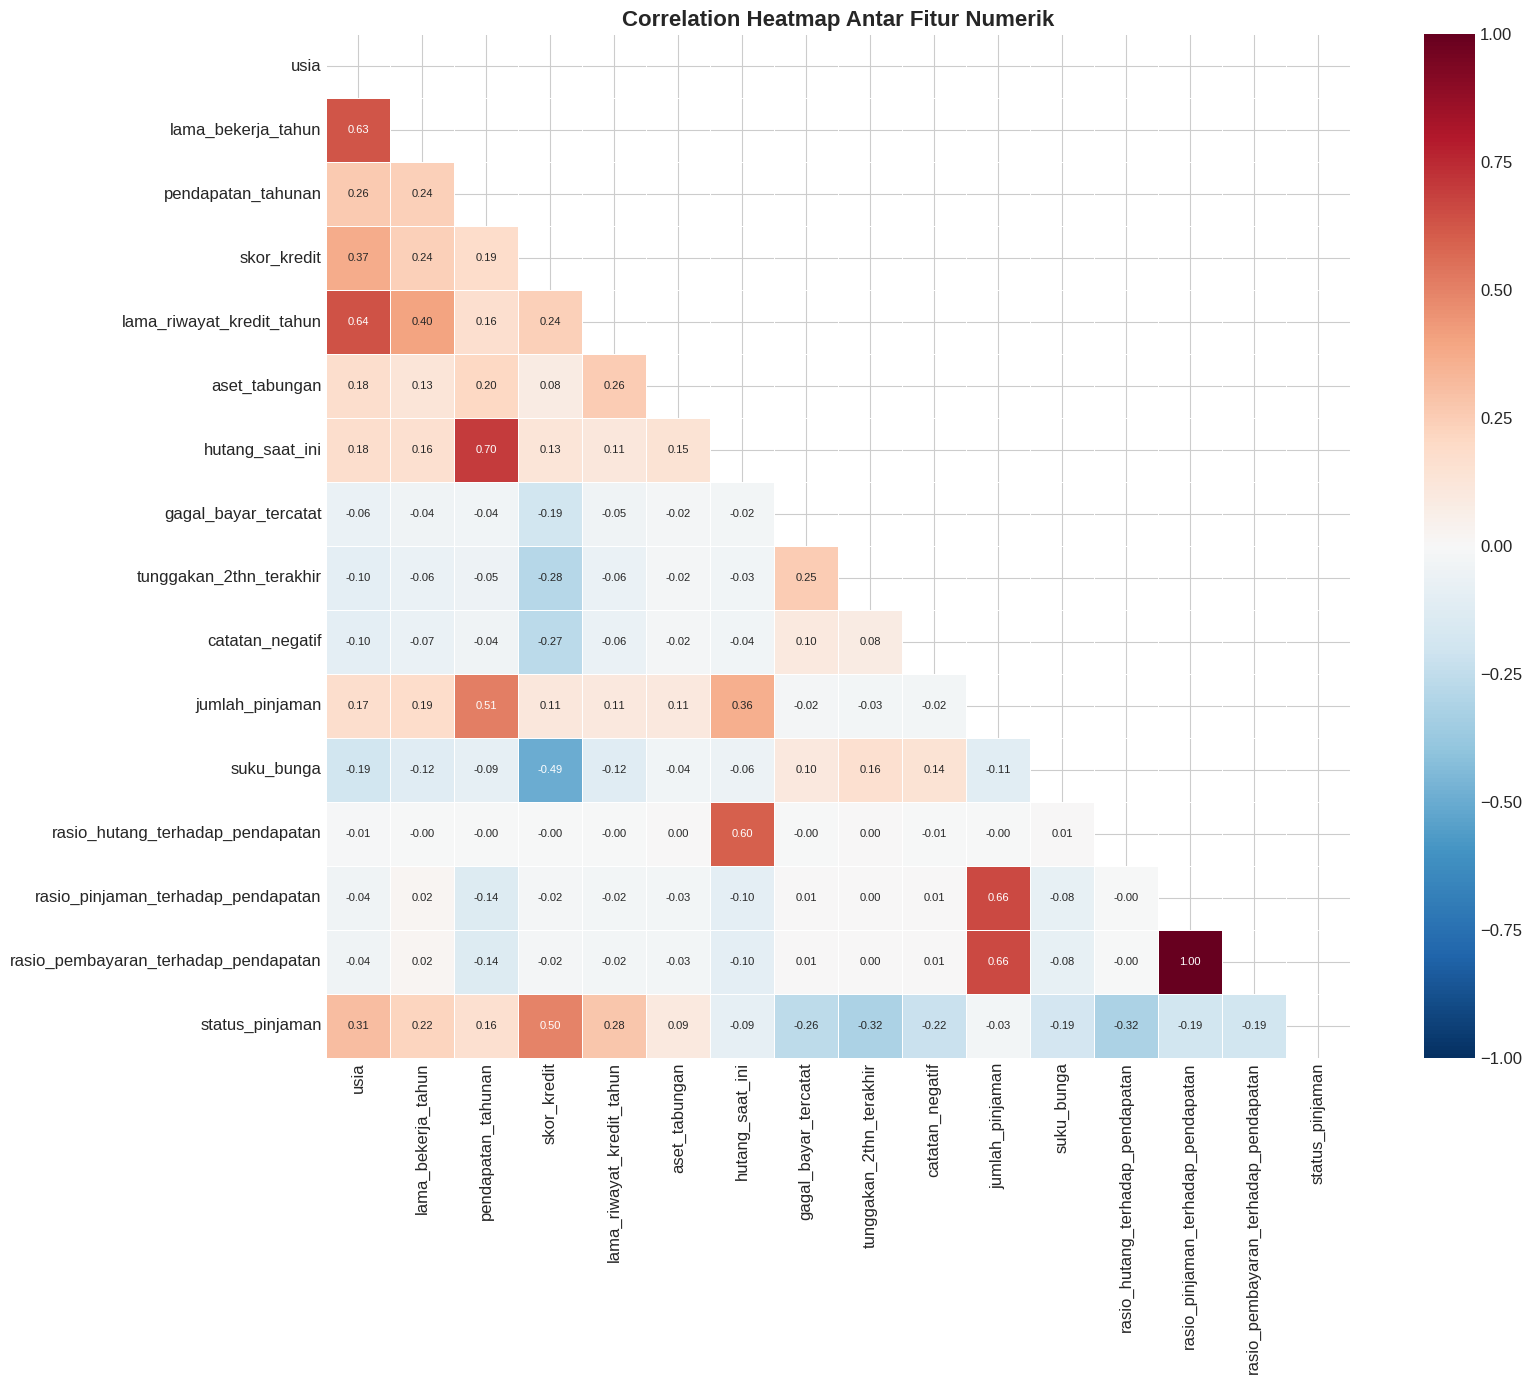


📊 Korelasi Fitur Numerik dengan Status Pinjaman (Target):
  skor_kredit                                   : +0.4963 (↑ Positif)
  usia                                          : +0.3112 (↑ Positif)
  lama_riwayat_kredit_tahun                     : +0.2771 (↑ Positif)
  lama_bekerja_tahun                            : +0.2189 (↑ Positif)
  pendapatan_tahunan                            : +0.1585 (↑ Positif)
  aset_tabungan                                 : +0.0948 (↑ Positif)
  jumlah_pinjaman                               : -0.0260 (↓ Negatif)
  hutang_saat_ini                               : -0.0885 (↓ Negatif)
  suku_bunga                                    : -0.1852 (↓ Negatif)
  rasio_pinjaman_terhadap_pendapatan            : -0.1933 (↓ Negatif)
  rasio_pembayaran_terhadap_pendapatan          : -0.1933 (↓ Negatif)
  catatan_negatif                               : -0.2247 (↓ Negatif)
  gagal_bayar_tercatat                          : -0.2630 (↓ Negatif)
  rasio_hutang_terhadap_pendapa

In [ ]:
# ============================================
# 4.4 Correlation Heatmap
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

# Gunakan hanya kolom numerik agar kompatibel dengan pandas versi baru
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Heatmap Antar Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\n📊 Korelasi Fitur Numerik dengan Status Pinjaman (Target):")
print("=" * 50)
corr_target = corr_matrix['status_pinjaman'].drop('status_pinjaman').sort_values(ascending=False)
for feat, corr_val in corr_target.items():
    direction = "↑ Positif" if corr_val > 0 else "↓ Negatif"
    print(f"  {feat:45s} : {corr_val:+.4f} ({direction})")


In [ ]:
# ============================================
# 4.5 Statistik Deskriptif per Kelas Target
# ============================================
print("📊 Statistik Deskriptif per Kelas Target:")
print("=" * 60)

print("\n🔴 Kelas 0 - Gagal Bayar:")
print(df[df['status_pinjaman'] == 0].describe().round(2))

print("\n🟢 Kelas 1 - Lunas:")
print(df[df['status_pinjaman'] == 1].describe().round(2))


📊 Statistik Deskriptif per Kelas Target:

🔴 Kelas 0 - Gagal Bayar:
           usia  lama_bekerja_tahun  pendapatan_tahunan  skor_kredit  \
count  22477.00            22477.00            22477.00     22477.00   
mean      31.14                5.61            44341.07       608.06   
std       10.31                6.59            27911.93        57.75   
min       18.00                0.00            15000.00       348.00   
25%       22.00                1.00            24674.00       571.00   
50%       30.00                2.90            37127.00       603.00   
75%       38.00                8.40            55614.00       643.00   
max       70.00               39.70           250000.00       850.00   

       lama_riwayat_kredit_tahun  aset_tabungan  hutang_saat_ini  \
count                   22477.00       22477.00         22477.00   
mean                        5.96        2207.67         15587.32   
std                         6.26        9678.78         14675.97   
min         

## 5. Cek Keseimbangan Kelas (Class Imbalance Check)

Pengecekan distribusi kelas pada variabel target sangat penting dilakukan **sebelum** membangun model. Data yang tidak seimbang dapat menyebabkan model bias terhadap kelas mayoritas.

**Kriteria:**
- Rasio > 1:1.5 → dianggap **imbalanced** dan perlu penanganan
- Rasio ≤ 1:1.5 → dianggap **relatif seimbang**

⚖️  ANALISIS KESEIMBANGAN KELAS

📊 Distribusi Kelas:
   Kelas 0 (Gagal Bayar) : 22,477 sampel (44.95%)
   Kelas 1 (Lunas)       : 27,523 sampel (55.05%)

   Kelas Mayoritas       : Lunas (1)
   Kelas Minoritas       : Gagal Bayar (0)

   Imbalance Ratio       : 1 : 1.22


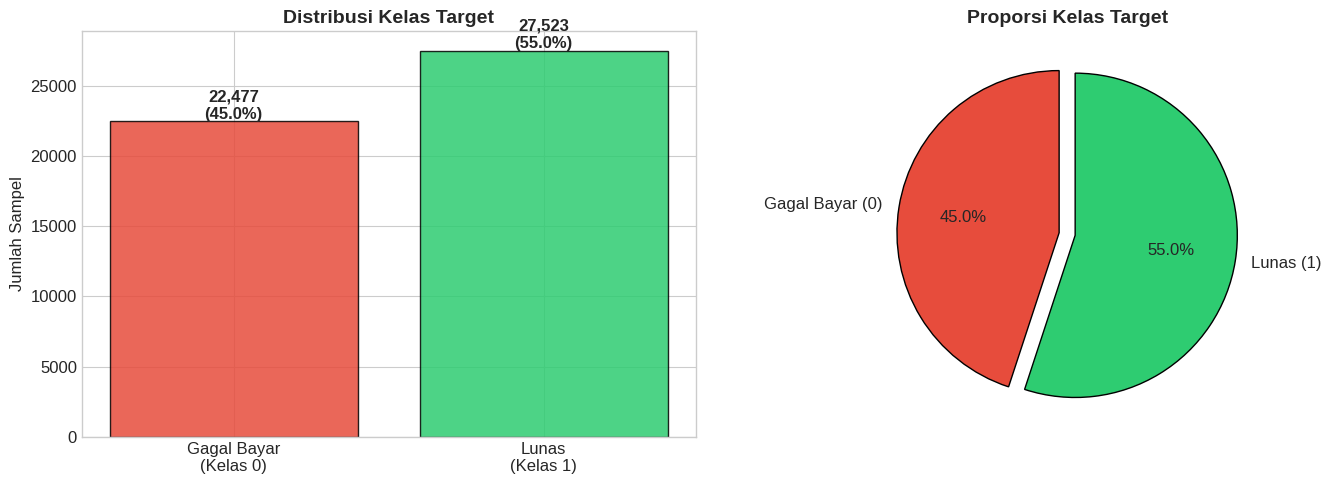


✅ KEPUTUSAN: Data RELATIF SEIMBANG (rasio 1:1.22)
   → Tidak memerlukan teknik oversampling wajib, namun SMOTE
     tetap dapat diterapkan untuk meningkatkan performa model


In [ ]:
# ============================================
# 5. Cek Keseimbangan Kelas
# ============================================
print("⚖️  ANALISIS KESEIMBANGAN KELAS")
print("=" * 60)

target_counts = df['status_pinjaman'].value_counts()
total = len(df)

kelas_0 = target_counts[0]  # Gagal Bayar
kelas_1 = target_counts[1]  # Lunas

majority = max(kelas_0, kelas_1)
minority = min(kelas_0, kelas_1)
imbalance_ratio = majority / minority

print(f"\n📊 Distribusi Kelas:")
print(f"   Kelas 0 (Gagal Bayar) : {kelas_0:,} sampel ({kelas_0/total*100:.2f}%)")
print(f"   Kelas 1 (Lunas)       : {kelas_1:,} sampel ({kelas_1/total*100:.2f}%)")
print(f"\n   Kelas Mayoritas       : {'Lunas (1)' if kelas_1 > kelas_0 else 'Gagal Bayar (0)'}")
print(f"   Kelas Minoritas       : {'Gagal Bayar (0)' if kelas_1 > kelas_0 else 'Lunas (1)'}")
print(f"\n   Imbalance Ratio       : 1 : {imbalance_ratio:.2f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(['Gagal Bayar\n(Kelas 0)', 'Lunas\n(Kelas 1)'],
                    [kelas_0, kelas_1],
                    color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, [kelas_0, kelas_1]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie([kelas_0, kelas_1],
            labels=['Gagal Bayar (0)', 'Lunas (1)'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05), textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Keputusan
print("\n" + "=" * 60)
if imbalance_ratio > 1.5:
    print(f"⚠️  KEPUTUSAN: Data TIDAK SEIMBANG (rasio 1:{imbalance_ratio:.2f})")
    print("   → Perlu penanganan dengan SMOTE pada data training")
    NEED_SMOTE = True
else:
    print(f"✅ KEPUTUSAN: Data RELATIF SEIMBANG (rasio 1:{imbalance_ratio:.2f})")
    print("   → Tidak memerlukan teknik oversampling wajib, namun SMOTE")
    print("     tetap dapat diterapkan untuk meningkatkan performa model")
    NEED_SMOTE = True  # Tetap terapkan SMOTE untuk best practice
print("=" * 60)

## 6. Preprocessing Lanjutan: Drop Kolom dan One-Hot Encoding

Setelah EDA dan pengecekan keseimbangan kelas, lakukan preprocessing lanjutan:
- Drop kolom tidak relevan (`id_pelanggan`) dan kolom yang mengandung **data leakage** (`gagal_bayar_tercatat`)
- **One-Hot Encoding** untuk mengubah variabel kategorikal menjadi representasi numerik tanpa urutan


In [ ]:
# ============================================
# 6. Drop Kolom Tidak Relevan & One-Hot Encoding
# ============================================

# Drop kolom ID (tidak relevan untuk modeling)
df.drop('id_pelanggan', axis=1, inplace=True)
print("🗑️  Kolom 'id_pelanggan' telah di-drop")

# Drop kolom 'gagal_bayar_tercatat' karena DATA LEAKAGE:
# Kolom ini bernilai 1 untuk 100% sampel Gagal Bayar dan 0 untuk sisanya,
# artinya kolom ini mengkodekan OUTCOME pinjaman saat ini (bukan riwayat kredit masa lalu).
# Menyertakan kolom ini berarti model "mengetahui" jawaban sebelum prediksi → leakage.
df.drop('gagal_bayar_tercatat', axis=1, inplace=True)
print("🗑️  Kolom 'gagal_bayar_tercatat' di-drop → DATA LEAKAGE (100% prediktif terhadap target)\n")

# Identifikasi kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"📋 Kolom Kategorikal yang akan di-encode (One-Hot): {cat_cols}\n")

# One-Hot Encoding untuk kolom kategorikal (tanpa urutan)
original_cols = df.columns.tolist()
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    new_cols = [c for c in df.columns if c not in original_cols]
else:
    new_cols = []

print(f"✅ One-Hot Encoding selesai. Kolom baru yang terbentuk: {len(new_cols)}")
if new_cols:
    preview = new_cols[:10]
    suffix = ' ...' if len(new_cols) > 10 else ''
    print(f"   Contoh kolom OHE: {preview}{suffix}")

print(f"\n{'='*50}")
print("✅ Semua kolom kategorikal berhasil di-encode (One-Hot)!")
print(f"Shape dataset setelah preprocessing: {df.shape}")
print(f"\nTipe data setiap kolom:")
print(df.dtypes)


🗑️  Kolom 'id_pelanggan' telah di-drop
🗑️  Kolom 'gagal_bayar_tercatat' di-drop → DATA LEAKAGE (100% prediktif terhadap target)

📋 Kolom Kategorikal yang akan di-encode (One-Hot): ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']

✅ One-Hot Encoding selesai. Kolom baru yang terbentuk: 12
   Contoh kolom OHE: ['status_pekerjaan_Employed', 'status_pekerjaan_Self-Employed', 'status_pekerjaan_Student', 'tipe_produk_Kartu Kredit', 'tipe_produk_Kredit Berjalan', 'tipe_produk_Pinjaman Pribadi', 'tujuan_pinjaman_Bisnis', 'tujuan_pinjaman_Konsolidasi Hutang', 'tujuan_pinjaman_Medis', 'tujuan_pinjaman_Pendidikan'] ...

✅ Semua kolom kategorikal berhasil di-encode (One-Hot)!
Shape dataset setelah preprocessing: (50000, 27)

Tipe data setiap kolom:
usia                                    float64
lama_bekerja_tahun                      float64
pendapatan_tahunan                        int64
skor_kredit                               int64
lama_riwayat_kredit_tahun               float64
aset_tab

## 7. Penanganan Ketidakseimbangan Kelas dengan SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** menghasilkan sampel sintetis untuk kelas minoritas berdasarkan interpolasi antara sampel-sampel yang berdekatan (k-nearest neighbors).

> ⚠️ **Penting (No Leakage):** SMOTE **tidak boleh** diterapkan ke seluruh dataset sebelum cross validation.
> SMOTE harus dilakukan **hanya pada data training di tiap fold**, sementara data validation/test tetap data asli.


📊 Distribusi Kelas TRAIN fold (sebelum SMOTE):
   Kelas 0 (Gagal Bayar): 17,982
   Kelas 1 (Lunas)      : 22,018

📊 Distribusi Kelas TRAIN fold (sesudah SMOTE):
   Kelas 0 (Gagal Bayar): 22,018
   Kelas 1 (Lunas)      : 22,018

📊 Distribusi Kelas VALIDATION fold (tetap asli, tanpa SMOTE):
   Kelas 0 (Gagal Bayar): 4,495
   Kelas 1 (Lunas)      : 5,505


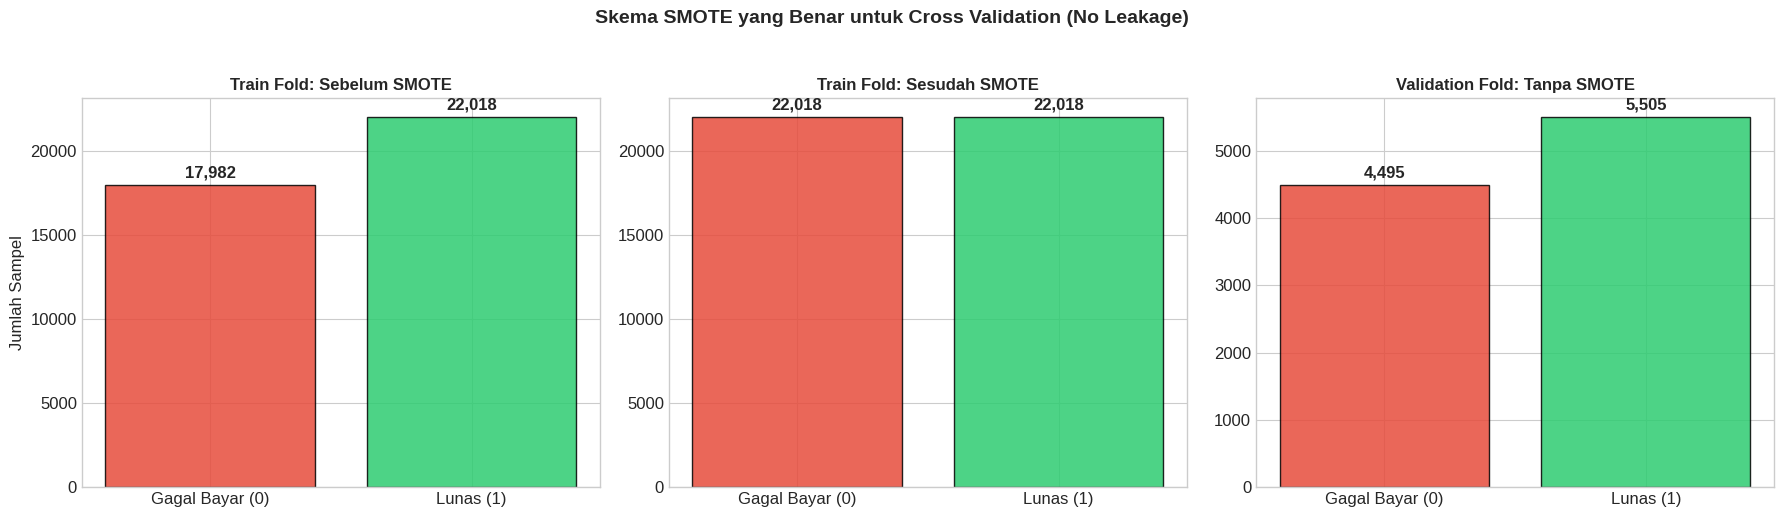

In [ ]:
# ============================================
# 7. Demonstrasi SMOTE TANPA Data Leakage
# ============================================
# Demonstrasi ini menunjukkan pola yang benar:
# 1) Split fold terlebih dahulu
# 2) SMOTE hanya pada data TRAIN fold
# 3) Data VALIDATION fold tetap asli

X_demo = df.drop('status_pinjaman', axis=1)
y_demo = df['status_pinjaman']

skf_demo = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx_demo, val_idx_demo = next(skf_demo.split(X_demo, y_demo))

X_train_demo = X_demo.iloc[train_idx_demo]
y_train_demo = y_demo.iloc[train_idx_demo]
X_val_demo = X_demo.iloc[val_idx_demo]
y_val_demo = y_demo.iloc[val_idx_demo]

smote_demo = SMOTE(random_state=42)
X_train_smote_demo, y_train_smote_demo = smote_demo.fit_resample(X_train_demo, y_train_demo)

print("📊 Distribusi Kelas TRAIN fold (sebelum SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_train_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_train_demo == 1).sum():,}")

print("\n📊 Distribusi Kelas TRAIN fold (sesudah SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_train_smote_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_train_smote_demo == 1).sum():,}")

print("\n📊 Distribusi Kelas VALIDATION fold (tetap asli, tanpa SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_val_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_val_demo == 1).sum():,}")

# Visualisasi ringkas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_before = [(y_train_demo == 0).sum(), (y_train_demo == 1).sum()]
train_after = [(y_train_smote_demo == 0).sum(), (y_train_smote_demo == 1).sum()]
val_orig = [(y_val_demo == 0).sum(), (y_val_demo == 1).sum()]

axes[0].bar(['Gagal Bayar (0)', 'Lunas (1)'], train_before,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Train Fold: Sebelum SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].bar(['Gagal Bayar (0)', 'Lunas (1)'], train_after,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[1].set_title('Train Fold: Sesudah SMOTE', fontsize=12, fontweight='bold')

axes[2].bar(['Gagal Bayar (0)', 'Lunas (1)'], val_orig,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[2].set_title('Validation Fold: Tanpa SMOTE', fontsize=12, fontweight='bold')

for ax, vals in zip(axes, [train_before, train_after, val_orig]):
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Skema SMOTE yang Benar untuk Cross Validation (No Leakage)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Bersihkan memory
del X_demo, y_demo, X_train_demo, y_train_demo, X_val_demo, y_val_demo

del X_train_smote_demo, y_train_smote_demo, skf_demo, train_idx_demo, val_idx_demo, smote_demo


## 8. Feature Selection dan Splitting Data

Pisahkan fitur (X) dan variabel target (y). Siapkan data untuk proses **Stratified K-Fold Cross Validation**.

**Mengapa Stratified K-Fold?**
- Mempertahankan proporsi kelas di setiap fold
- Lebih representatif dibandingkan K-Fold biasa untuk data imbalanced
- Menghasilkan estimasi performa yang lebih reliable


In [ ]:
# ============================================
# 8. Splitting Data dan Persiapan Cross Validation
# ============================================

# Pisahkan fitur dan target
X = df.drop('status_pinjaman', axis=1)
y = df['status_pinjaman']

feature_names = X.columns.tolist()

print("📋 Fitur yang digunakan untuk modeling:")
print("=" * 50)
for i, col in enumerate(feature_names, 1):
    print(f"  {i:2d}. {col}")
print(f"\nTotal fitur: {len(feature_names)}")
print(f"Total sampel: {len(X):,}")
print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Catatan: StandardScaler TIDAK digunakan karena Random Forest dan XGBoost
# adalah model berbasis pohon (tree-based) yang tidak sensitif terhadap skala fitur.
# Menggunakan StandardScaler pada seluruh dataset sebelum CV juga berisiko
# menyebabkan DATA LEAKAGE (scaler melihat data validasi saat fit).
print(f"\n✅ Tidak diperlukan StandardScaler untuk model tree-based (RF & XGBoost)")
print(f"   → Menghindari potensi data leakage dari fitting scaler pada seluruh data")

# Setup Stratified K-Fold
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
print(f"\n✅ Stratified {N_SPLITS}-Fold Cross Validation siap digunakan")

# Verifikasi proporsi di setiap fold
print(f"\n📊 Verifikasi Proporsi Kelas di Setiap Fold:")
print("-" * 50)
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    train_ratio = y_train_fold.value_counts(normalize=True)
    val_ratio = y_val_fold.value_counts(normalize=True)
    print(f"  Fold {fold:2d} | Train: 0={train_ratio[0]:.3f}, 1={train_ratio[1]:.3f} | "
          f"Val: 0={val_ratio[0]:.3f}, 1={val_ratio[1]:.3f} | "
          f"Train={len(train_idx):,}, Val={len(val_idx):,}")


📋 Fitur yang digunakan untuk modeling:
   1. usia
   2. lama_bekerja_tahun
   3. pendapatan_tahunan
   4. skor_kredit
   5. lama_riwayat_kredit_tahun
   6. aset_tabungan
   7. hutang_saat_ini
   8. tunggakan_2thn_terakhir
   9. catatan_negatif
  10. jumlah_pinjaman
  11. suku_bunga
  12. rasio_hutang_terhadap_pendapatan
  13. rasio_pinjaman_terhadap_pendapatan
  14. rasio_pembayaran_terhadap_pendapatan
  15. status_pekerjaan_Employed
  16. status_pekerjaan_Self-Employed
  17. status_pekerjaan_Student
  18. tipe_produk_Kartu Kredit
  19. tipe_produk_Kredit Berjalan
  20. tipe_produk_Pinjaman Pribadi
  21. tujuan_pinjaman_Bisnis
  22. tujuan_pinjaman_Konsolidasi Hutang
  23. tujuan_pinjaman_Medis
  24. tujuan_pinjaman_Pendidikan
  25. tujuan_pinjaman_Pribadi
  26. tujuan_pinjaman_Renovasi Rumah

Total fitur: 26
Total sampel: 50,000

Shape X: (50000, 26)
Shape y: (50000,)

✅ Tidak diperlukan StandardScaler untuk model tree-based (RF & XGBoost)
   → Menghindari potensi data leakage dari fi

## 9. Membangun Model Random Forest dengan Stratified K-Fold Cross Validation

Random Forest adalah algoritma ensemble berbasis **bagging** yang membangun banyak pohon keputusan secara paralel dan menggabungkan prediksinya melalui voting.

**Hyperparameter tuning:** dilakukan dengan **GridSearchCV** (scoring F1) menggunakan **Stratified K-Fold** dan **pipeline SMOTE** agar tidak terjadi leakage.

Pada setiap fold evaluasi:
1. Data training di-SMOTE untuk menyeimbangkan kelas
2. Model Random Forest dilatih pada data training
3. Evaluasi pada data validation (tanpa SMOTE)
4. Metrik disimpan: Accuracy, Precision, Recall, F1-Score, AUC


In [ ]:
# ============================================
# 9. Model Random Forest + Stratified K-Fold CV
# ============================================
print("🌲 TRAINING RANDOM FOREST dengan Stratified K-Fold Cross Validation")
print("=" * 70)

# 9.1 Hyperparameter Tuning dengan GridSearchCV (SMOTE di dalam pipeline)
print("\n🔍 GridSearchCV - Random Forest (scoring = F1)")

rf_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1))
])

rf_grid_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    scoring='f1',
    cv=rf_grid_cv,
    n_jobs=-1
)

rf_grid.fit(X, y)

rf_best_params = {k.replace('model__', ''): v for k, v in rf_grid.best_params_.items()}

rf_params = {
    **rf_best_params,
    'random_state': 42,
    'n_jobs': -1
}

print("✅ Best Params RF:", rf_params)
print(f"✅ Best CV F1 RF : {rf_grid.best_score_:.4f}")

print(f"\n📋 Hyperparameter Random Forest (hasil GridSearchCV):")
for k, v in rf_params.items():
    print(f"   {k}: {v}")

# Storage untuk metrik per fold
rf_metrics = {
    'accuracy': [], 'precision': [], 'recall': [],
    'f1_score': [], 'f2_score': [], 'auc': []
}

# Storage untuk prediksi dan model terbaik
rf_best_f1 = 0
rf_best_model = None
rf_best_y_true = None
rf_best_y_pred = None
rf_best_y_prob = None
rf_best_val_idx = None
rf_all_importances = []

smote = SMOTE(random_state=42)

print(f"\n{'='*70}")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'F2-Score':>10} {'AUC':>10}")
print(f"{'='*70}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    # Split data (tanpa scaling - tree-based model tidak memerlukan scaling)
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Terapkan SMOTE pada data training (HANYA training, bukan validasi → no leakage)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_fold, y_train_fold)

    # Training model
    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train_smote, y_train_smote)

    # Prediksi
    y_pred = rf_model.predict(X_val_fold)
    y_prob = rf_model.predict_proba(X_val_fold)[:, 1]

    # Hitung metrik
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec = recall_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
    f2 = fbeta_score(y_val_fold, y_pred, beta=2, zero_division=0)
    auc = roc_auc_score(y_val_fold, y_prob)

    # Simpan metrik
    rf_metrics['accuracy'].append(acc)
    rf_metrics['precision'].append(prec)
    rf_metrics['recall'].append(rec)
    rf_metrics['f1_score'].append(f1)
    rf_metrics['f2_score'].append(f2)
    rf_metrics['auc'].append(auc)

    # Simpan feature importance
    rf_all_importances.append(rf_model.feature_importances_)

    # Track model terbaik (berdasarkan F1)
    if f1 > rf_best_f1:
        rf_best_f1 = f1
        rf_best_model = rf_model
        rf_best_y_true = y_val_fold
        rf_best_y_pred = y_pred
        rf_best_y_prob = y_prob
        rf_best_val_idx = val_idx

    print(f"  {fold:<4} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f2:>10.4f} {auc:>10.4f}")

print(f"{'='*70}")
print(f"  {'Mean':<4} {np.mean(rf_metrics['accuracy']):>10.4f} {np.mean(rf_metrics['precision']):>10.4f} "
      f"{np.mean(rf_metrics['recall']):>10.4f} {np.mean(rf_metrics['f1_score']):>10.4f} "
      f"{np.mean(rf_metrics['f2_score']):>10.4f} {np.mean(rf_metrics['auc']):>10.4f}")
print(f"  {'Std':<4} {np.std(rf_metrics['accuracy']):>10.4f} {np.std(rf_metrics['precision']):>10.4f} "
      f"{np.std(rf_metrics['recall']):>10.4f} {np.std(rf_metrics['f1_score']):>10.4f} "
      f"{np.std(rf_metrics['f2_score']):>10.4f} {np.std(rf_metrics['auc']):>10.4f}")
print(f"{'='*70}")

# Rata-rata feature importance
rf_avg_importance = np.mean(rf_all_importances, axis=0)

print("\n✅ Training Random Forest selesai!")


🌲 TRAINING RANDOM FOREST dengan Stratified K-Fold Cross Validation

🔍 GridSearchCV - Random Forest (scoring = F1)
✅ Best Params RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300, 'random_state': 42, 'n_jobs': -1}
✅ Best CV F1 RF : 0.9080

📋 Hyperparameter Random Forest (hasil GridSearchCV):
   max_depth: None
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 300
   random_state: 42
   n_jobs: -1

Fold     Accuracy  Precision     Recall   F1-Score   F2-Score        AUC
  1        0.9022     0.9143     0.9074     0.9108     0.9088     0.9637
  2        0.9024     0.9141     0.9081     0.9111     0.9093     0.9665
  3        0.8920     0.8993     0.9052     0.9022     0.9040     0.9600
  4        0.8990     0.9069     0.9099     0.9084     0.9093     0.9675
  5        0.8964     0.9162     0.8935     0.9047     0.8980     0.9636
  6        0.9044     0.9199     0.9052     0.9125     0.9081     0.9667
  7        0.9040     0.9161     0

In [ ]:
# Classification Report dari fold terbaik Random Forest
print("📋 Classification Report - Random Forest (Fold Terbaik):")
print("=" * 60)
print(classification_report(rf_best_y_true, rf_best_y_pred,
                            target_names=['Gagal Bayar (0)', 'Lunas (1)']))

📋 Classification Report - Random Forest (Fold Terbaik):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.89      0.90      0.89      2248
      Lunas (1)       0.92      0.91      0.91      2752

       accuracy                           0.90      5000
      macro avg       0.90      0.90      0.90      5000
   weighted avg       0.90      0.90      0.90      5000



### 9.1 F2-Score & Estimasi Kerugian Finansial (Random Forest)

**F2-Score** (dengan Beta=2) memberikan bobot lebih pada **Recall** dibandingkan Precision. Dalam kasus kredit, **jauh lebih buruk meloloskan nasabah gagal bayar (False Negative)** daripada menolak nasabah yang sebenarnya mampu bayar (False Positive). Oleh karena itu, kita memantau F2-Score secara ketat.

Berikut adalah estimasi kerugian finansial pada fold terbaik:

In [ ]:
from sklearn.metrics import confusion_matrix

# Perhitungan kerugian finansial pada fold terbaik Random Forest
AVG_LOAN_AMOUNT = 33042
RECOVERY_RATE = 0.30

cm_rf = confusion_matrix(rf_best_y_true, rf_best_y_pred)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

loss_per_fn = AVG_LOAN_AMOUNT * (1 - RECOVERY_RATE)
cost_per_fp = AVG_LOAN_AMOUNT * 0.05

total_fn_loss_rf = fn_rf * loss_per_fn
total_fp_cost_rf = fp_rf * cost_per_fp
total_cost_rf = total_fn_loss_rf + total_fp_cost_rf

print("💸 Estimasi Kerugian Finansial - Random Forest (Fold Terbaik)")
print("-" * 60)
print(f"  Kerugian per False Negative (Gagal Bayar) : Rp {loss_per_fn:,.0f}")
print(f"  Opportunity Cost per False Positive       : Rp {cost_per_fp:,.0f}")
print(f"  Total Kerugian Gagal Bayar ({fn_rf:,} kasus)      : Rp {total_fn_loss_rf:,.0f}")
print(f"  Total Opportunity Cost ({fp_rf:,} kasus)          : Rp {total_fp_cost_rf:,.0f}")
print(f"  TOTAL ESTIMASI KERUGIAN                   : Rp {total_cost_rf:,.0f}")


💸 Estimasi Kerugian Finansial - Random Forest (Fold Terbaik)
------------------------------------------------------------
  Kerugian per False Negative (Gagal Bayar) : Rp 23,129
  Opportunity Cost per False Positive       : Rp 1,652
  Total Kerugian Gagal Bayar (261 kasus)      : Rp 6,036,773
  Total Opportunity Cost (217 kasus)          : Rp 358,506
  TOTAL ESTIMASI KERUGIAN                   : Rp 6,395,279


## 10. Membangun Model XGBoost dengan Stratified K-Fold Cross Validation

XGBoost (Extreme Gradient Boosting) adalah algoritma ensemble berbasis **boosting** yang membangun pohon keputusan secara sekuensial, di mana setiap pohon baru berusaha memperbaiki kesalahan dari pohon sebelumnya.

**Hyperparameter tuning:** dilakukan dengan **GridSearchCV** (scoring F1) menggunakan **Stratified K-Fold** dan **pipeline SMOTE** agar tidak terjadi leakage.

Proses evaluasi identik dengan Random Forest: SMOTE pada data training, evaluasi pada data validation asli.


In [ ]:
# ============================================
# 10. Model XGBoost + Stratified K-Fold CV
# ============================================
print("🚀 TRAINING XGBOOST dengan Stratified K-Fold Cross Validation")
print("=" * 70)

# 10.1 Hyperparameter Tuning dengan GridSearchCV (SMOTE di dalam pipeline)
print("\n🔍 GridSearchCV - XGBoost (scoring = F1)")

xgb_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        n_jobs=1,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ))
])

xgb_grid_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    scoring='f1',
    cv=xgb_grid_cv,
    n_jobs=-1
)

xgb_grid.fit(X, y)

xgb_best_params = {k.replace('model__', ''): v for k, v in xgb_grid.best_params_.items()}

xgb_params = {
    **xgb_best_params,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

print("✅ Best Params XGB:", xgb_params)
print(f"✅ Best CV F1 XGB : {xgb_grid.best_score_:.4f}")

print(f"\n📋 Hyperparameter XGBoost (hasil GridSearchCV):")
for k, v in xgb_params.items():
    print(f"   {k}: {v}")

# Storage untuk metrik per fold
xgb_metrics = {
    'accuracy': [], 'precision': [], 'recall': [],
    'f1_score': [], 'f2_score': [], 'auc': []
}

# Storage untuk prediksi dan model terbaik
xgb_best_f1 = 0
xgb_best_model = None
xgb_best_y_true = None
xgb_best_y_pred = None
xgb_best_y_prob = None
xgb_best_val_idx = None
xgb_all_importances = []

print(f"\n{'='*70}")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'F2-Score':>10} {'AUC':>10}")
print(f"{'='*70}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    # Split data (tanpa scaling - tree-based model tidak memerlukan scaling)
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Terapkan SMOTE pada data training (HANYA training, bukan validasi → no leakage)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_fold, y_train_fold)

    # Training model
    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train_smote, y_train_smote, verbose=False)

    # Prediksi
    y_pred = xgb_model.predict(X_val_fold)
    y_prob = xgb_model.predict_proba(X_val_fold)[:, 1]

    # Hitung metrik
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec = recall_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
    f2 = fbeta_score(y_val_fold, y_pred, beta=2, zero_division=0)
    auc = roc_auc_score(y_val_fold, y_prob)

    # Simpan metrik
    xgb_metrics['accuracy'].append(acc)
    xgb_metrics['precision'].append(prec)
    xgb_metrics['recall'].append(rec)
    xgb_metrics['f1_score'].append(f1)
    xgb_metrics['f2_score'].append(f2)
    xgb_metrics['auc'].append(auc)

    # Simpan feature importance
    xgb_all_importances.append(xgb_model.feature_importances_)

    # Track model terbaik (berdasarkan F1)
    if f1 > xgb_best_f1:
        xgb_best_f1 = f1
        xgb_best_model = xgb_model
        xgb_best_y_true = y_val_fold
        xgb_best_y_pred = y_pred
        xgb_best_y_prob = y_prob
        xgb_best_val_idx = val_idx

    print(f"  {fold:<4} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f2:>10.4f} {auc:>10.4f}")

print(f"{'='*70}")
print(f"  {'Mean':<4} {np.mean(xgb_metrics['accuracy']):>10.4f} {np.mean(xgb_metrics['precision']):>10.4f} "
      f"{np.mean(xgb_metrics['recall']):>10.4f} {np.mean(xgb_metrics['f1_score']):>10.4f} "
      f"{np.mean(xgb_metrics['f2_score']):>10.4f} {np.mean(xgb_metrics['auc']):>10.4f}")
print(f"  {'Std':<4} {np.std(xgb_metrics['accuracy']):>10.4f} {np.std(xgb_metrics['precision']):>10.4f} "
      f"{np.std(xgb_metrics['recall']):>10.4f} {np.std(xgb_metrics['f1_score']):>10.4f} "
      f"{np.std(xgb_metrics['f2_score']):>10.4f} {np.std(xgb_metrics['auc']):>10.4f}")
print(f"{'='*70}")

# Rata-rata feature importance
xgb_avg_importance = np.mean(xgb_all_importances, axis=0)

print("\n✅ Training XGBoost selesai!")


🚀 TRAINING XGBOOST dengan Stratified K-Fold Cross Validation

🔍 GridSearchCV - XGBoost (scoring = F1)
✅ Best Params XGB: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8, 'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
✅ Best CV F1 XGB : 0.9254

📋 Hyperparameter XGBoost (hasil GridSearchCV):
   colsample_bytree: 1.0
   learning_rate: 0.1
   max_depth: 4
   n_estimators: 300
   subsample: 0.8
   use_label_encoder: False
   eval_metric: logloss
   random_state: 42
   n_jobs: -1
   verbosity: 0

Fold     Accuracy  Precision     Recall   F1-Score   F2-Score        AUC
  1        0.9194     0.9158     0.9401     0.9278     0.9351     0.9750
  2        0.9232     0.9244     0.9372     0.9307     0.9346     0.9764
  3        0.9116     0.9073     0.9350     0.9209     0.9293     0.9733
  4        0.9228     0.9204     0.9411     0.9307     0.9369     0.9778
  5        0.9162     0.9259

### Ringkasan Rentang Hyperparameter yang Diuji (GridSearchCV)

Berikut adalah rentang hiperparameter spesifik yang diuji menggunakan pencarian ekstensif `GridSearchCV` untuk mengoptimalkan **F1-Score**:

#### Random Forest (24 Kombinasi)
| Hyperparameter | Rentang Nilai | Penjelasan |
| --- | --- | --- |
| `n_estimators` | `[200, 300]` | Jumlah pohon dalam ensemble. |
| `max_depth` | `[10, 15, None]` | Kedalaman maksimal setiap pohon. |
| `min_samples_split` | `[2, 5]` | Jumlah sampel minimal untuk memecah node. |
| `min_samples_leaf` | `[1, 2]` | Jumlah sampel minimal pada daun (leaf). |

#### XGBoost (32 Kombinasi)
| Hyperparameter | Rentang Nilai | Penjelasan |
| --- | --- | --- |
| `n_estimators` | `[200, 300]` | Jumlah boosting rounds (pohon). |
| `max_depth` | `[4, 6]` | Kedalaman pohon. |
| `learning_rate` | `[0.05, 0.1]` | Step size shrinkage untuk mencegah overfitting. |
| `subsample` | `[0.8, 1.0]` | Fraksi observasi yang disampling secara acak tiap pohon. |
| `colsample_bytree` | `[0.8, 1.0]` | Fraksi fitur yang disampling tiap pohon. |


In [78]:
# Classification Report dari fold terbaik XGBoost
print("📋 Classification Report - XGBoost (Fold Terbaik):")
print("=" * 60)
print(classification_report(xgb_best_y_true, xgb_best_y_pred,
                            target_names=['Gagal Bayar (0)', 'Lunas (1)']))

📋 Classification Report - XGBoost (Fold Terbaik):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.92      0.91      0.91      2247
      Lunas (1)       0.92      0.94      0.93      2753

       accuracy                           0.92      5000
      macro avg       0.92      0.92      0.92      5000
   weighted avg       0.92      0.92      0.92      5000



### 10.1 F2-Score & Estimasi Kerugian Finansial (XGBoost)

Sama seperti pada Random Forest, kita akan menghitung F2-Score dan estimasi kerugian finansial untuk model XGBoost pada fold terbaiknya.

In [79]:
cm_xgb = confusion_matrix(xgb_best_y_true, xgb_best_y_pred)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

total_fn_loss_xgb = fn_xgb * loss_per_fn
total_fp_cost_xgb = fp_xgb * cost_per_fp
total_cost_xgb = total_fn_loss_xgb + total_fp_cost_xgb

print("💸 Estimasi Kerugian Finansial - XGBoost (Fold Terbaik)")
print("-" * 60)
print(f"  Total Kerugian Gagal Bayar ({fn_xgb:,} kasus)      : Rp {total_fn_loss_xgb:,.0f}")
print(f"  Total Opportunity Cost ({fp_xgb:,} kasus)          : Rp {total_fp_cost_xgb:,.0f}")
print(f"  TOTAL ESTIMASI KERUGIAN                   : Rp {total_cost_xgb:,.0f}")


💸 Estimasi Kerugian Finansial - XGBoost (Fold Terbaik)
------------------------------------------------------------
  Total Kerugian Gagal Bayar (173 kasus)      : Rp 4,001,386
  Total Opportunity Cost (211 kasus)          : Rp 348,593
  TOTAL ESTIMASI KERUGIAN                   : Rp 4,349,979


## 11. Perbandingan Metrik Kinerja Kedua Model

Membandingkan rata-rata dan standar deviasi dari setiap metrik evaluasi (Accuracy, Precision, Recall, F1-Score, AUC) antara Random Forest dan XGBoost melalui tabel ringkasan dan visualisasi.


In [80]:
# ============================================
# 11.1 Tabel Perbandingan Metrik
# ============================================
print("📊 PERBANDINGAN KINERJA RANDOM FOREST vs XGBOOST")
print("=" * 70)

metrics_list = ['accuracy', 'precision', 'recall', 'f1_score', 'f2_score', 'auc']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F2-Score', 'AUC']

comparison_data = []
for metric, label in zip(metrics_list, metrics_labels):
    rf_mean = np.mean(rf_metrics[metric])
    rf_std = np.std(rf_metrics[metric])
    xgb_mean = np.mean(xgb_metrics[metric])
    xgb_std = np.std(xgb_metrics[metric])
    winner = 'Random Forest' if rf_mean > xgb_mean else 'XGBoost' if xgb_mean > rf_mean else 'Seri'

    comparison_data.append({
        'Metrik': label,
        'RF Mean': f'{rf_mean:.4f}',
        'RF Std': f'±{rf_std:.4f}',
        'XGB Mean': f'{xgb_mean:.4f}',
        'XGB Std': f'±{xgb_std:.4f}',
        'Unggul': winner
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Hitung winner
rf_wins = sum(1 for d in comparison_data if d['Unggul'] == 'Random Forest')
xgb_wins = sum(1 for d in comparison_data if d['Unggul'] == 'XGBoost')
print(f"\n🏆 Random Forest unggul di {rf_wins} metrik")
print(f"🏆 XGBoost unggul di {xgb_wins} metrik")


📊 PERBANDINGAN KINERJA RANDOM FOREST vs XGBOOST
   Metrik RF Mean  RF Std XGB Mean XGB Std  Unggul
 Accuracy  0.8999 ±0.0038   0.9184 ±0.0036 XGBoost
Precision  0.9111 ±0.0058   0.9194 ±0.0057 XGBoost
   Recall  0.9066 ±0.0054   0.9336 ±0.0062 XGBoost
 F1-Score  0.9088 ±0.0034   0.9264 ±0.0032 XGBoost
 F2-Score  0.9075 ±0.0042   0.9307 ±0.0046 XGBoost
      AUC  0.9644 ±0.0023   0.9753 ±0.0014 XGBoost

🏆 Random Forest unggul di 0 metrik
🏆 XGBoost unggul di 6 metrik


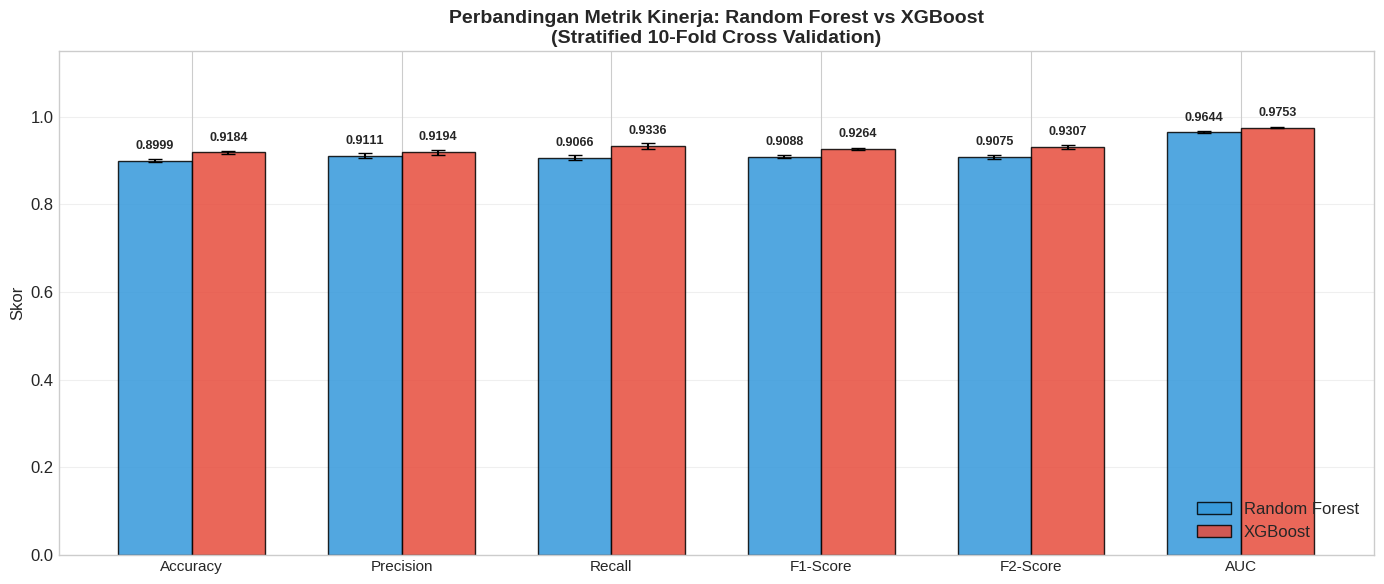

In [81]:
# ============================================
# 11.2 Grouped Bar Chart Perbandingan Metrik
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_labels))
width = 0.35

rf_means = [np.mean(rf_metrics[m]) for m in metrics_list]
xgb_means = [np.mean(xgb_metrics[m]) for m in metrics_list]
rf_stds = [np.std(rf_metrics[m]) for m in metrics_list]
xgb_stds = [np.std(xgb_metrics[m]) for m in metrics_list]

bars1 = ax.bar(x - width/2, rf_means, width, yerr=rf_stds, label='Random Forest',
               color='#3498db', edgecolor='black', alpha=0.85, capsize=5)
bars2 = ax.bar(x + width/2, xgb_means, width, yerr=xgb_stds, label='XGBoost',
               color='#e74c3c', edgecolor='black', alpha=0.85, capsize=5)

ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Metrik Kinerja: Random Forest vs XGBoost\n(Stratified 10-Fold Cross Validation)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for bar, val in zip(bars1, rf_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, xgb_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


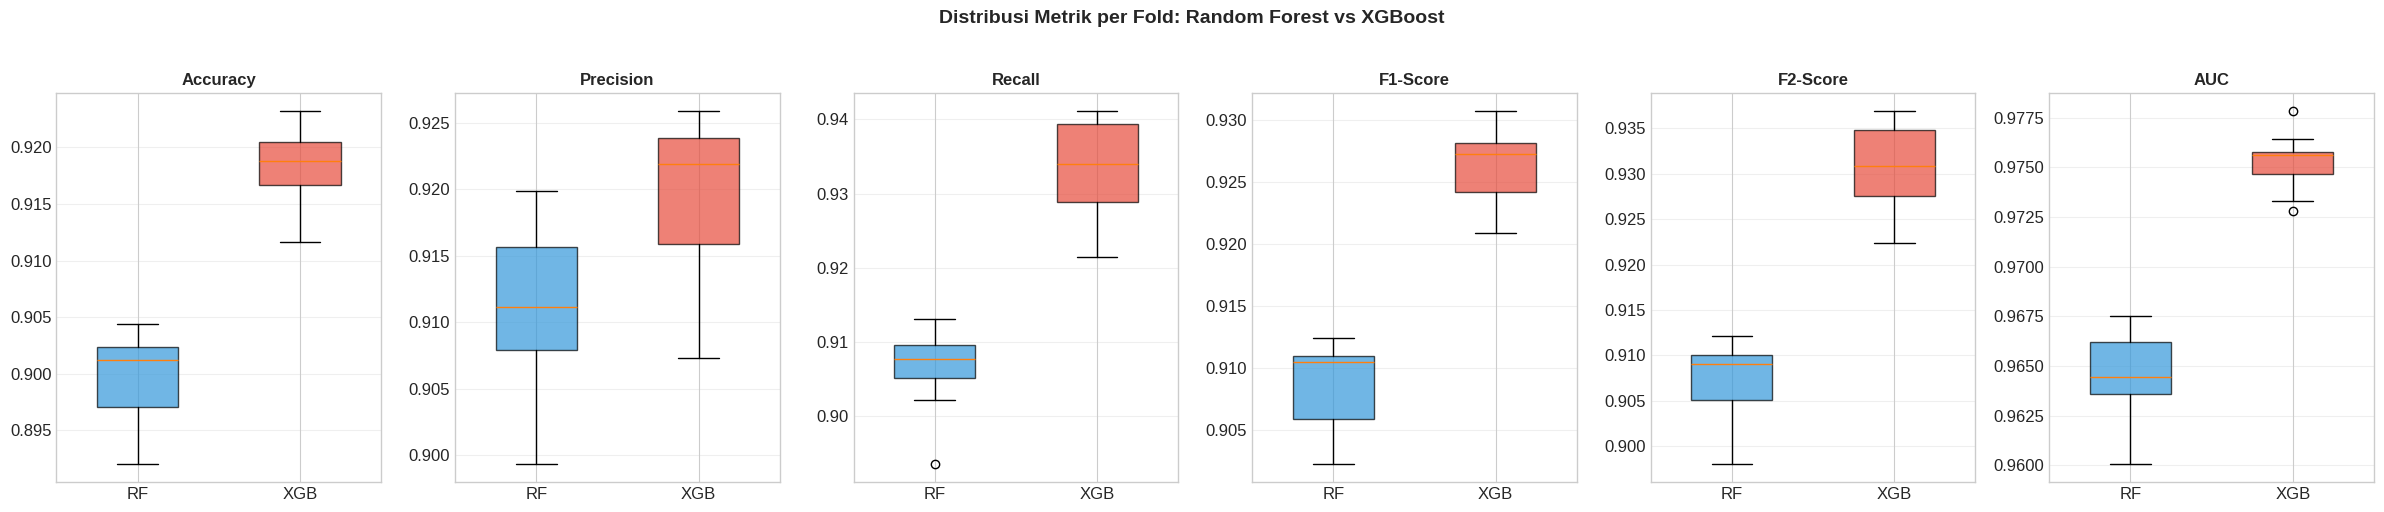

In [82]:
# ============================================
# 11.3 Boxplot Distribusi Metrik per Fold
# ============================================
fig, axes = plt.subplots(1, len(metrics_list), figsize=(24, 5))

for i, (metric, label) in enumerate(zip(metrics_list, metrics_labels)):
    data_to_plot = [rf_metrics[metric], xgb_metrics[metric]]
    ax = axes[i] if len(metrics_list) > 1 else axes
    bp = ax.boxplot(data_to_plot, labels=['RF', 'XGB'], patch_artist=True,
                     widths=0.5)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.7)
        box.set_edgecolor('black')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Metrik per Fold: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 12. Analisis Feature Importance - Random Forest

Feature importance pada Random Forest dihitung berdasarkan **Mean Decrease in Impurity (MDI)**, yaitu seberapa besar kontribusi rata-rata setiap fitur dalam mengurangi impurity (Gini) di seluruh pohon dalam forest.


🌲 FEATURE IMPORTANCE - RANDOM FOREST
 Ranking                                Fitur  Importance  Importance (%)
       1                          skor_kredit    0.224513           22.45
       2     rasio_hutang_terhadap_pendapatan    0.170294           17.03
       3                           suku_bunga    0.070483            7.05
       4            lama_riwayat_kredit_tahun    0.063227            6.32
       5              tunggakan_2thn_terakhir    0.052708            5.27
       6                                 usia    0.045989            4.60
       7   rasio_pinjaman_terhadap_pendapatan    0.045922            4.59
       8 rasio_pembayaran_terhadap_pendapatan    0.043113            4.31
       9                   lama_bekerja_tahun    0.038911            3.89
      10                      hutang_saat_ini    0.037505            3.75
      11                        aset_tabungan    0.034982            3.50
      12                   pendapatan_tahunan    0.031536            3.15
 

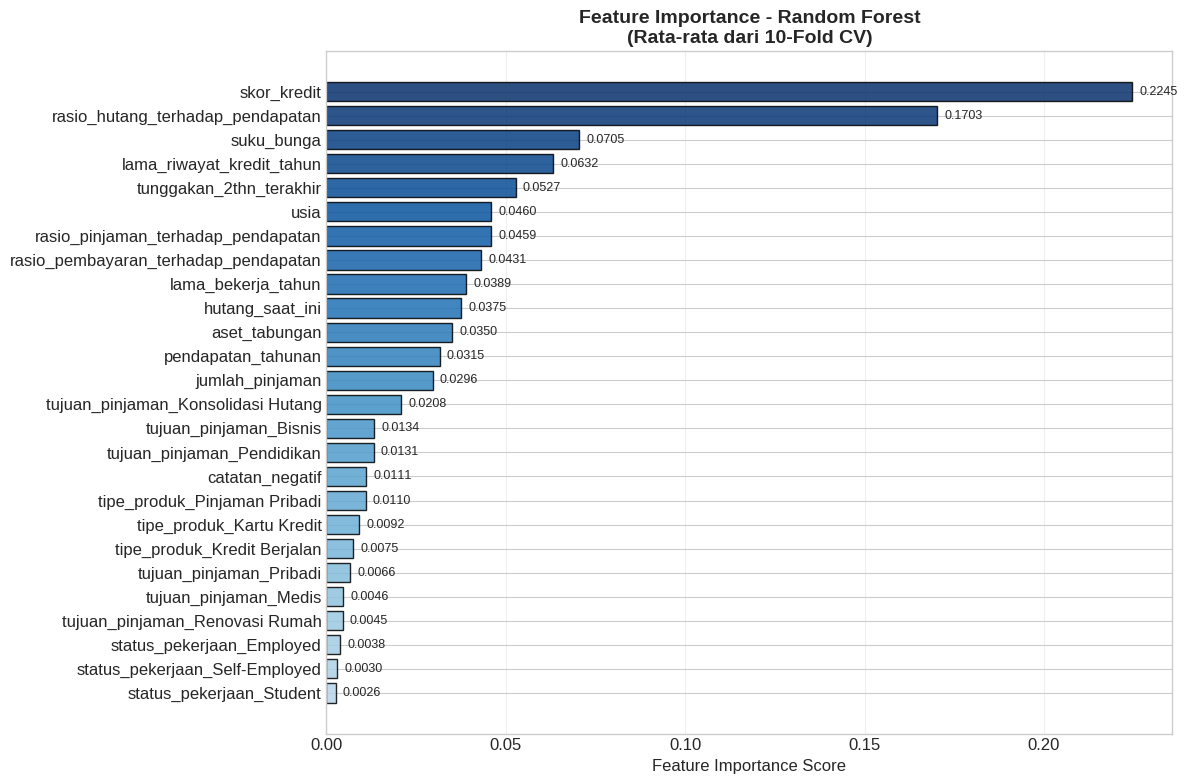

In [83]:
# ============================================
# 12. Feature Importance - Random Forest
# ============================================
print("🌲 FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 60)

# Buat DataFrame feature importance
rf_fi_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': rf_avg_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_fi_df['Ranking'] = range(1, len(rf_fi_df) + 1)
rf_fi_df['Importance (%)'] = (rf_fi_df['Importance'] / rf_fi_df['Importance'].sum() * 100).round(2)

print(rf_fi_df[['Ranking', 'Fitur', 'Importance', 'Importance (%)']].to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))

rf_fi_sorted = rf_fi_df.sort_values('Importance', ascending=True)
colors = plt.cm.Blues(np.linspace(0.3, 1, len(rf_fi_sorted)))

bars = ax.barh(rf_fi_sorted['Fitur'], rf_fi_sorted['Importance'],
               color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance - Random Forest\n(Rata-rata dari 10-Fold CV)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for bar, val in zip(bars, rf_fi_sorted['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 13. Analisis Feature Importance - XGBoost

Feature importance pada XGBoost dihitung berdasarkan **gain**, yaitu rata-rata peningkatan performa (pengurangan loss) yang dihasilkan oleh fitur tersebut setiap kali digunakan untuk splitting.


🚀 FEATURE IMPORTANCE - XGBOOST
 Ranking                                Fitur  Importance  Importance (%)
       1                          skor_kredit    0.155578           15.56
       2     rasio_hutang_terhadap_pendapatan    0.110326           11.03
       3              tunggakan_2thn_terakhir    0.070699            7.07
       4   tujuan_pinjaman_Konsolidasi Hutang    0.067689            6.77
       5               tujuan_pinjaman_Bisnis    0.054314            5.43
       6 rasio_pembayaran_terhadap_pendapatan    0.048806            4.88
       7         tipe_produk_Pinjaman Pribadi    0.048476            4.85
       8            lama_riwayat_kredit_tahun    0.048472            4.85
       9             tipe_produk_Kartu Kredit    0.044038            4.40
      10   rasio_pinjaman_terhadap_pendapatan    0.043484            4.35
      11          tipe_produk_Kredit Berjalan    0.039321            3.93
      12           tujuan_pinjaman_Pendidikan    0.029918            2.99
      1

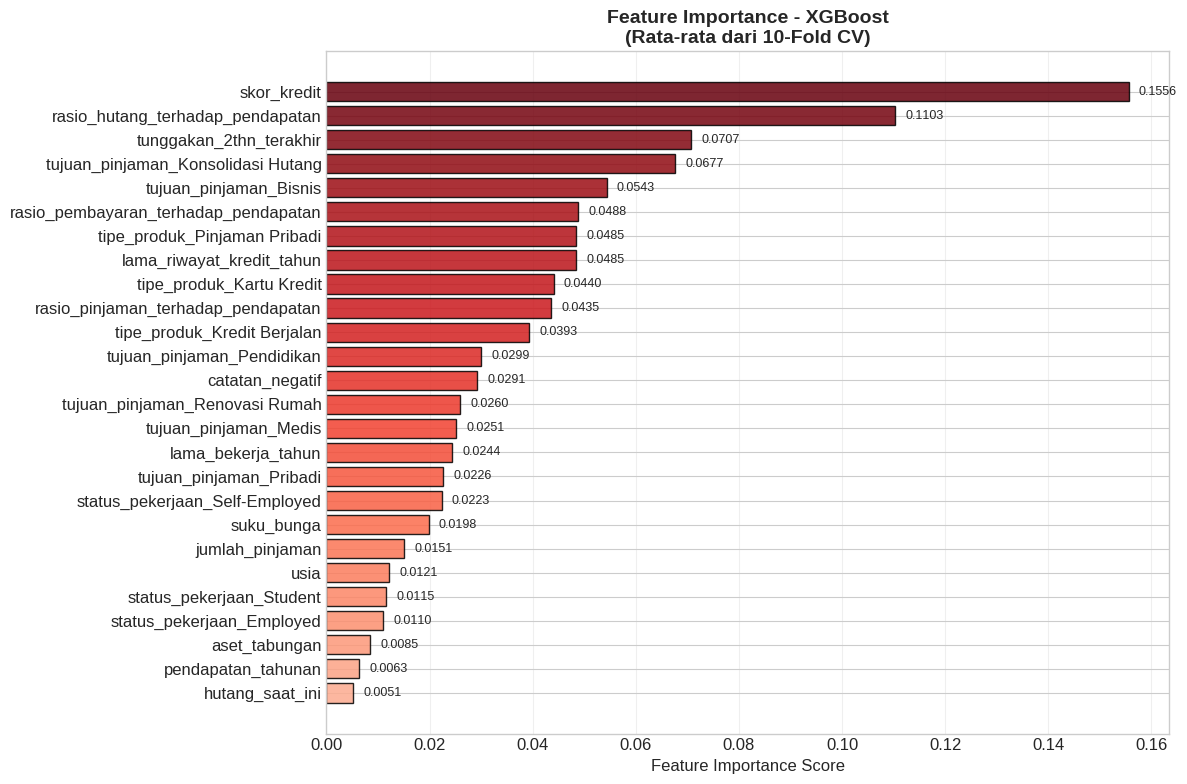

In [84]:
# ============================================
# 13. Feature Importance - XGBoost
# ============================================
print("🚀 FEATURE IMPORTANCE - XGBOOST")
print("=" * 60)

# Buat DataFrame feature importance
xgb_fi_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': xgb_avg_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_fi_df['Ranking'] = range(1, len(xgb_fi_df) + 1)
xgb_fi_df['Importance (%)'] = (xgb_fi_df['Importance'] / xgb_fi_df['Importance'].sum() * 100).round(2)

print(xgb_fi_df[['Ranking', 'Fitur', 'Importance', 'Importance (%)']].to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))

xgb_fi_sorted = xgb_fi_df.sort_values('Importance', ascending=True)
colors = plt.cm.Reds(np.linspace(0.3, 1, len(xgb_fi_sorted)))

bars = ax.barh(xgb_fi_sorted['Fitur'], xgb_fi_sorted['Importance'],
               color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance - XGBoost\n(Rata-rata dari 10-Fold CV)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, xgb_fi_sorted['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 14. Perbandingan Feature Importance Kedua Model

Membandingkan ranking feature importance dari Random Forest dan XGBoost secara side-by-side untuk mengidentifikasi fitur yang konsisten penting di kedua model.


📊 PERBANDINGAN RANKING FEATURE IMPORTANCE
                               Fitur  RF Rank  RF Importance  XGB Rank  XGB Importance  Selisih Rank
                         skor_kredit        1       0.224513         1        0.155578             0
    rasio_hutang_terhadap_pendapatan        2       0.170294         2        0.110326             0
                          suku_bunga        3       0.070483        19        0.019809            16
           lama_riwayat_kredit_tahun        4       0.063227         8        0.048472             4
             tunggakan_2thn_terakhir        5       0.052708         3        0.070699             2
                                usia        6       0.045989        21        0.012109            15
  rasio_pinjaman_terhadap_pendapatan        7       0.045922        10        0.043484             3
rasio_pembayaran_terhadap_pendapatan        8       0.043113         6        0.048806             2
                  lama_bekerja_tahun        9    

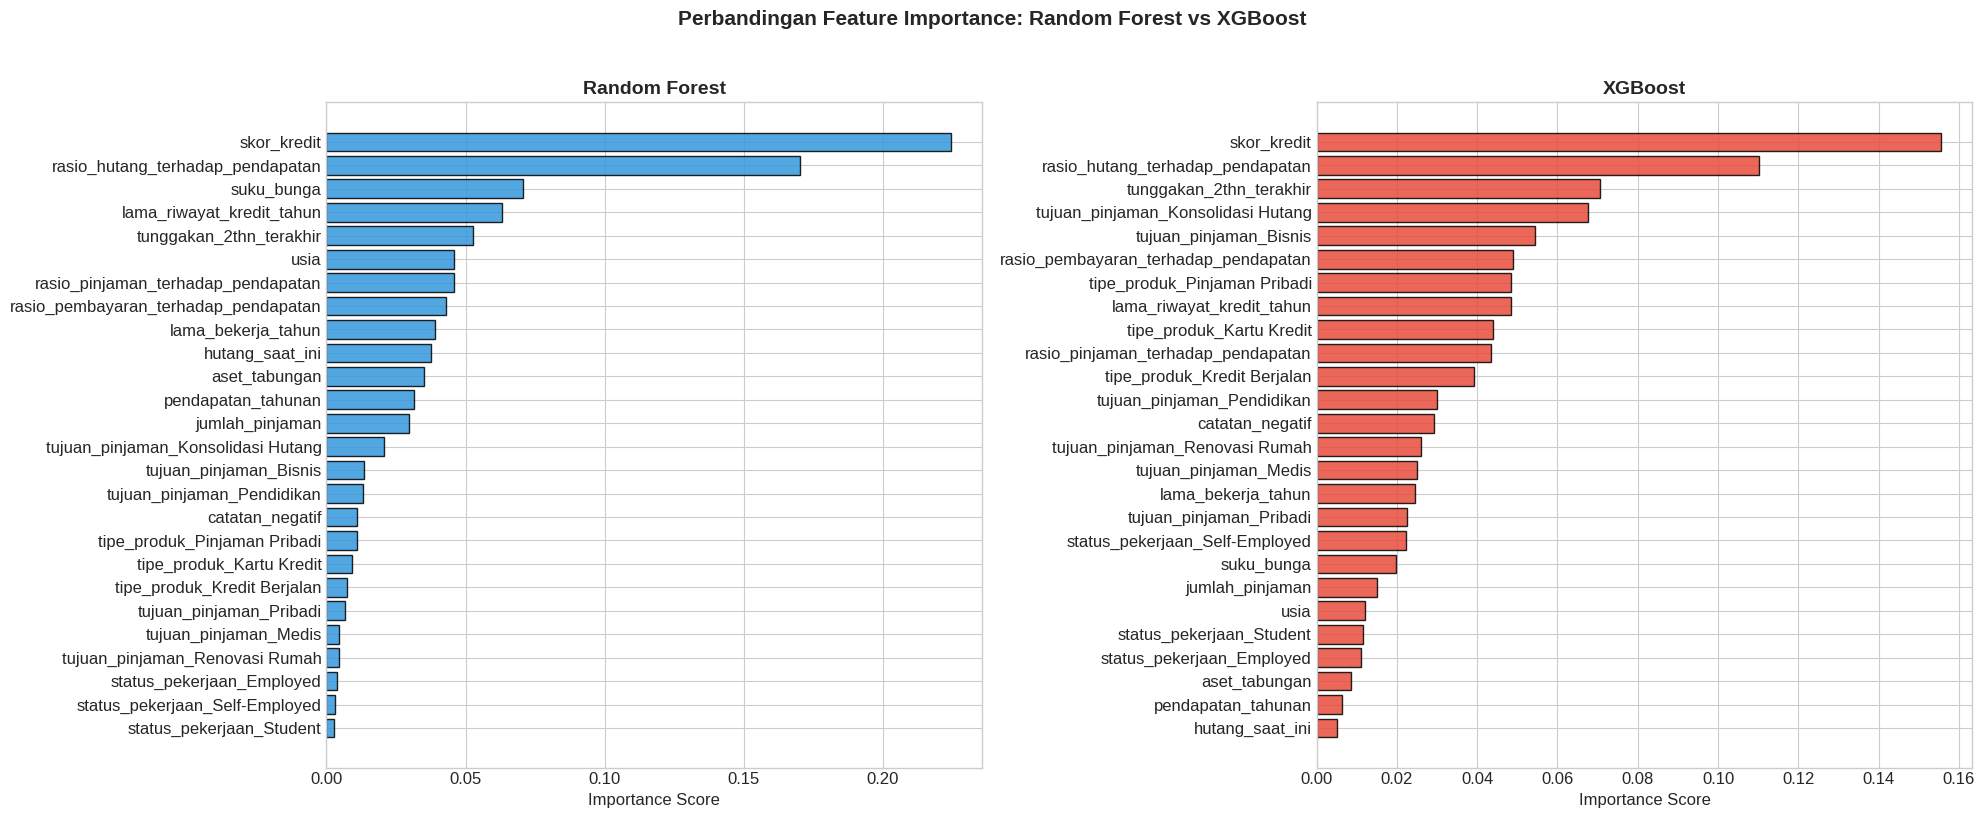


🔑 Top 5 Fitur Random Forest  : {'skor_kredit', 'tunggakan_2thn_terakhir', 'rasio_hutang_terhadap_pendapatan', 'lama_riwayat_kredit_tahun', 'suku_bunga'}
🔑 Top 5 Fitur XGBoost        : {'skor_kredit', 'tujuan_pinjaman_Konsolidasi Hutang', 'tunggakan_2thn_terakhir', 'tujuan_pinjaman_Bisnis', 'rasio_hutang_terhadap_pendapatan'}
✅ Fitur Konsisten Penting     : {'skor_kredit', 'tunggakan_2thn_terakhir', 'rasio_hutang_terhadap_pendapatan'}


In [85]:
# ============================================
# 14. Perbandingan Feature Importance
# ============================================
print("📊 PERBANDINGAN RANKING FEATURE IMPORTANCE")
print("=" * 70)

# Buat tabel ranking perbandingan
ranking_comparison = pd.DataFrame({
    'Fitur': feature_names,
    'RF Importance': rf_avg_importance,
    'XGB Importance': xgb_avg_importance
})

# Hitung ranking
ranking_comparison['RF Rank'] = ranking_comparison['RF Importance'].rank(ascending=False).astype(int)
ranking_comparison['XGB Rank'] = ranking_comparison['XGB Importance'].rank(ascending=False).astype(int)
ranking_comparison['Selisih Rank'] = abs(ranking_comparison['RF Rank'] - ranking_comparison['XGB Rank'])
ranking_comparison = ranking_comparison.sort_values('RF Rank')

print(ranking_comparison[['Fitur', 'RF Rank', 'RF Importance', 'XGB Rank', 'XGB Importance', 'Selisih Rank']].to_string(index=False))

# Visualisasi side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest
rf_sorted = ranking_comparison.sort_values('RF Importance', ascending=True)
axes[0].barh(rf_sorted['Fitur'], rf_sorted['RF Importance'],
             color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_sorted = ranking_comparison.sort_values('XGB Importance', ascending=True)
axes[1].barh(xgb_sorted['Fitur'], xgb_sorted['XGB Importance'],
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Perbandingan Feature Importance: Random Forest vs XGBoost',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Fitur konsisten penting (top 5 di kedua model)
rf_top5 = set(ranking_comparison.nsmallest(5, 'RF Rank')['Fitur'])
xgb_top5 = set(ranking_comparison.nsmallest(5, 'XGB Rank')['Fitur'])
consistent_top = rf_top5.intersection(xgb_top5)

print(f"\n🔑 Top 5 Fitur Random Forest  : {rf_top5}")
print(f"🔑 Top 5 Fitur XGBoost        : {xgb_top5}")
print(f"✅ Fitur Konsisten Penting     : {consistent_top if consistent_top else 'Tidak ada'}")


## 15. Visualisasi Confusion Matrix Kedua Model

Confusion matrix menunjukkan distribusi prediksi benar dan salah untuk setiap kelas, membantu mengidentifikasi tipe kesalahan yang paling sering terjadi di masing-masing model.


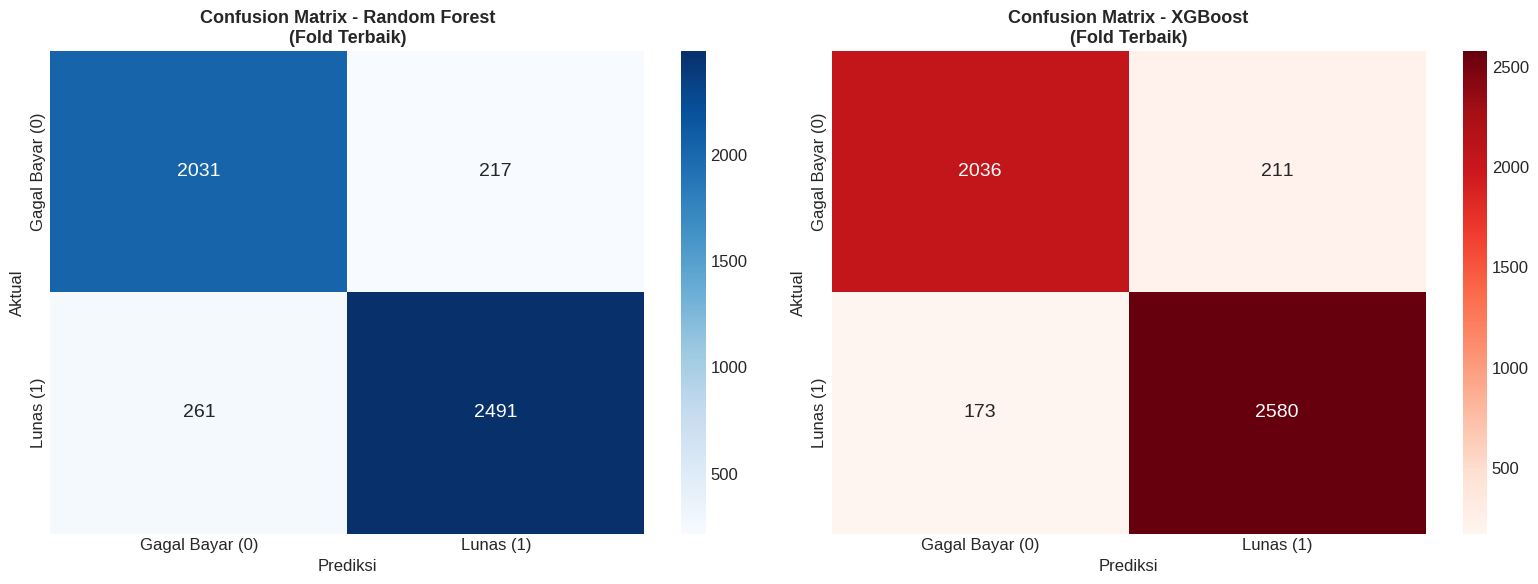


📊 Detail Confusion Matrix:

  Random Forest:
    True Negative  (TN) : 2,031 → Benar prediksi Gagal Bayar
    True Positive  (TP) : 2,491 → Benar prediksi Lunas
    False Positive (FP) : 217 → Salah prediksi Lunas (padahal Gagal Bayar)
    False Negative (FN) : 261 → Salah prediksi Gagal Bayar (padahal Lunas)

  XGBoost:
    True Negative  (TN) : 2,036 → Benar prediksi Gagal Bayar
    True Positive  (TP) : 2,580 → Benar prediksi Lunas
    False Positive (FP) : 211 → Salah prediksi Lunas (padahal Gagal Bayar)
    False Negative (FN) : 173 → Salah prediksi Gagal Bayar (padahal Lunas)

💰 Estimasi Kerugian Finansial (asumsi sederhana):
   Asumsi: kerugian FP = 1.00 x jumlah_pinjaman, kerugian FN = 0.05 x jumlah_pinjaman

  Random Forest:
    Total nominal FP (default) : 7,212,700
    Total nominal FN (lolos)   : 9,294,000
    Estimasi kerugian FP       : 7,212,700
    Estimasi kerugian FN       : 464,700
    Estimasi kerugian total    : 7,677,400

  XGBoost:
    Total nominal FP (default)

In [86]:
# ============================================
# 15. Confusion Matrix Kedua Model
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(rf_best_y_true, rf_best_y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Random Forest\n(Fold Terbaik)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Aktual', fontsize=12)
axes[0].set_xlabel('Prediksi', fontsize=12)

# Confusion Matrix - XGBoost
cm_xgb = confusion_matrix(xgb_best_y_true, xgb_best_y_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix - XGBoost\n(Fold Terbaik)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Aktual', fontsize=12)
axes[1].set_xlabel('Prediksi', fontsize=12)

plt.tight_layout()
plt.show()

# Detail angka
print("\n📊 Detail Confusion Matrix:")
print("=" * 60)
for name, cm in [('Random Forest', cm_rf), ('XGBoost', cm_xgb)]:
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  {name}:")
    print(f"    True Negative  (TN) : {tn:,} → Benar prediksi Gagal Bayar")
    print(f"    True Positive  (TP) : {tp:,} → Benar prediksi Lunas")
    print(f"    False Positive (FP) : {fp:,} → Salah prediksi Lunas (padahal Gagal Bayar)")
    print(f"    False Negative (FN) : {fn:,} → Salah prediksi Gagal Bayar (padahal Lunas)")

# Estimasi kerugian finansial sederhana dari fold terbaik
print("\n💰 Estimasi Kerugian Finansial (asumsi sederhana):")
loan_col = 'jumlah_pinjaman'
default_loss_rate = 1.0
opportunity_loss_rate = 0.05
print(f"   Asumsi: kerugian FP = {default_loss_rate:.2f} x {loan_col}, kerugian FN = {opportunity_loss_rate:.2f} x {loan_col}")

def estimate_loss(model_name, y_true, y_pred, val_idx):
    if val_idx is None:
        print(f"  {model_name}: indeks fold terbaik tidak tersedia.")
        return
    if loan_col not in X.columns:
        print(f"  {model_name}: kolom '{loan_col}' tidak ditemukan, estimasi dilewati.")
        return
    eval_df = X.loc[val_idx, [loan_col]].copy()
    eval_df['y_true'] = y_true.values
    eval_df['y_pred'] = y_pred
    fp_amount = eval_df.loc[(eval_df['y_true'] == 0) & (eval_df['y_pred'] == 1), loan_col].sum()
    fn_amount = eval_df.loc[(eval_df['y_true'] == 1) & (eval_df['y_pred'] == 0), loan_col].sum()
    loss_fp = fp_amount * default_loss_rate
    loss_fn = fn_amount * opportunity_loss_rate
    total_loss = loss_fp + loss_fn
    print(f"\n  {model_name}:")
    print(f"    Total nominal FP (default) : {fp_amount:,.0f}")
    print(f"    Total nominal FN (lolos)   : {fn_amount:,.0f}")
    print(f"    Estimasi kerugian FP       : {loss_fp:,.0f}")
    print(f"    Estimasi kerugian FN       : {loss_fn:,.0f}")
    print(f"    Estimasi kerugian total    : {total_loss:,.0f}")

estimate_loss('Random Forest', rf_best_y_true, rf_best_y_pred, rf_best_val_idx)
estimate_loss('XGBoost', xgb_best_y_true, xgb_best_y_pred, xgb_best_val_idx)


## 16. Visualisasi ROC Curve dan AUC Score Kedua Model

ROC Curve (Receiver Operating Characteristic) menggambarkan kemampuan diskriminasi model pada berbagai threshold. **AUC** (Area Under Curve) yang lebih tinggi menunjukkan model yang lebih baik dalam membedakan kelas positif dan negatif.


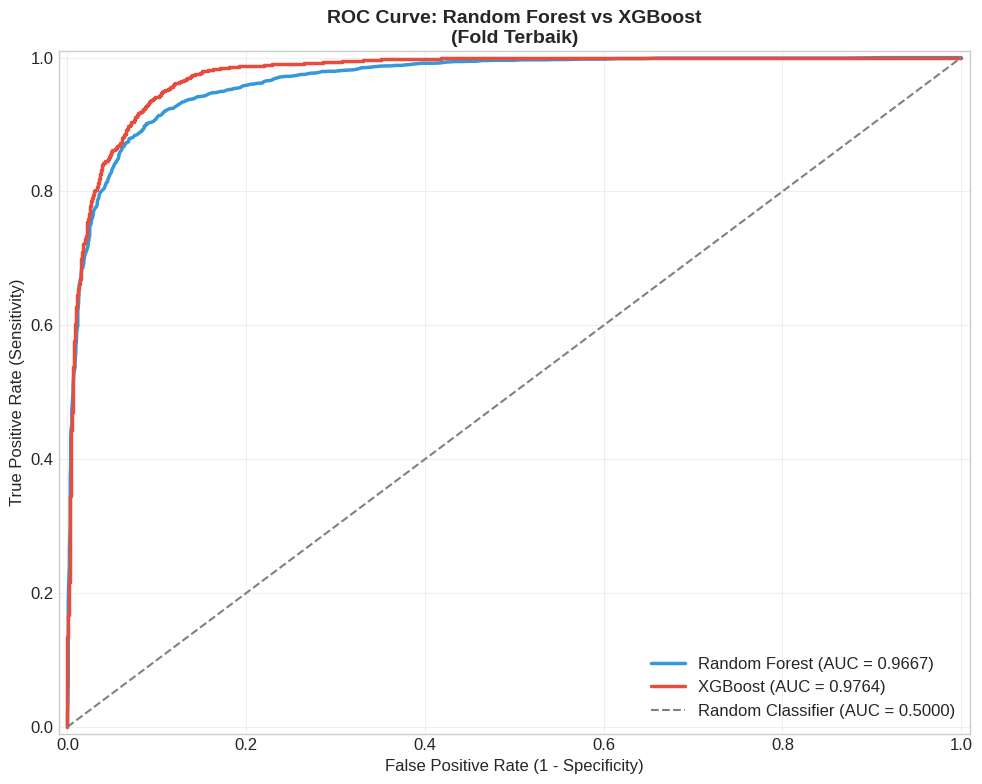


📊 Perbandingan AUC Score:
   Random Forest : 0.9667
   XGBoost       : 0.9764

   → XGBoost memiliki kemampuan diskriminasi lebih baik (+0.0097)


In [87]:
# ============================================
# 16. ROC Curve dan AUC Score
# ============================================
fig, ax = plt.subplots(figsize=(10, 8))

# ROC - Random Forest
fpr_rf, tpr_rf, _ = roc_curve(rf_best_y_true, rf_best_y_prob)
auc_rf = roc_auc_score(rf_best_y_true, rf_best_y_prob)
ax.plot(fpr_rf, tpr_rf, color='#3498db', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_rf:.4f})')

# ROC - XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(xgb_best_y_true, xgb_best_y_prob)
auc_xgb = roc_auc_score(xgb_best_y_true, xgb_best_y_prob)
ax.plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2.5,
        label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Garis diagonal (random classifier)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5,
        label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve: Random Forest vs XGBoost\n(Fold Terbaik)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

# Analisis
print(f"\n📊 Perbandingan AUC Score:")
print(f"   Random Forest : {auc_rf:.4f}")
print(f"   XGBoost       : {auc_xgb:.4f}")
if auc_rf > auc_xgb:
    print(f"\n   → Random Forest memiliki kemampuan diskriminasi lebih baik (+{auc_rf-auc_xgb:.4f})")
else:
    print(f"\n   → XGBoost memiliki kemampuan diskriminasi lebih baik (+{auc_xgb-auc_rf:.4f})")


## 17. Uji Statistik Perbandingan Kinerja Model (Paired t-test)

Untuk menentukan apakah perbedaan kinerja antara kedua model **signifikan secara statistik**, dilakukan **Paired t-test** pada metrik dari setiap fold.

**Hipotesis:**
- **H₀ (Null):** Tidak ada perbedaan signifikan antara kinerja Random Forest dan XGBoost
- **H₁ (Alternatif):** Terdapat perbedaan signifikan antara kinerja Random Forest dan XGBoost
- **Significance Level (α):** 0.05


In [88]:
# ============================================
# 17. Paired t-test
# ============================================
print("📊 UJI STATISTIK: PAIRED T-TEST")
print("=" * 70)
print(f"Significance Level (α) = 0.05")
print(f"Jumlah Fold            = {N_SPLITS}")
print()

alpha = 0.05
ttest_results = []

for metric, label in zip(metrics_list, metrics_labels):
    t_stat, p_value = ttest_rel(rf_metrics[metric], xgb_metrics[metric])
    significant = "Ya ✅" if p_value < alpha else "Tidak ❌"
    decision = "Tolak H₀" if p_value < alpha else "Gagal Tolak H₀"

    ttest_results.append({
        'Metrik': label,
        't-statistic': t_stat,
        'p-value': p_value,
        'Signifikan': significant,
        'Keputusan': decision
    })

ttest_df = pd.DataFrame(ttest_results)

for _, row in ttest_df.iterrows():
    print(f"  📌 {row['Metrik']}:")
    print(f"     t-statistic = {row['t-statistic']:.4f}")
    print(f"     p-value     = {row['p-value']:.6f}")
    print(f"     Signifikan  = {row['Signifikan']}")
    print(f"     Keputusan   = {row['Keputusan']}")
    print()

print("=" * 70)
print("\n📋 Ringkasan Paired t-test:")
print(ttest_df.to_string(index=False))


📊 UJI STATISTIK: PAIRED T-TEST
Significance Level (α) = 0.05
Jumlah Fold            = 10

  📌 Accuracy:
     t-statistic = -21.5849
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 Precision:
     t-statistic = -6.3718
     p-value     = 0.000130
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 Recall:
     t-statistic = -20.5669
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 F1-Score:
     t-statistic = -23.0515
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 F2-Score:
     t-statistic = -23.4357
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 AUC:
     t-statistic = -27.3262
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀


📋 Ringkasan Paired t-test:
   Metrik  t-statistic      p-value Signifikan Keputusan
 Accuracy   -21.584880 4.629423e-09       Ya ✅  Tolak H₀
Precision    -6.371760 1.295068e-04  

## 18. Kesimpulan


In [89]:
# ============================================
# 18. Kesimpulan Akhir
# ============================================
print("=" * 70)
print("📝 KESIMPULAN AKHIR")
print("=" * 70)

print(f"\n1️⃣  DATASET:")
print(f"   - Total data: 50,000 sampel dengan 17 fitur")
print(f"   - Kolom di-drop: 'id_pelanggan' (ID) & 'gagal_bayar_tercatat' (leakage)")
print(f"   - Target: status_pinjaman (0=Gagal Bayar, 1=Lunas)")

print(f"\n2️⃣  KESEIMBANGAN DATA:")
print(f"   - Kelas 0 (Gagal Bayar): {kelas_0:,} ({kelas_0/total*100:.1f}%)")
print(f"   - Kelas 1 (Lunas)      : {kelas_1:,} ({kelas_1/total*100:.1f}%)")
print(f"   - Imbalance Ratio      : 1:{imbalance_ratio:.2f}")
print(f"   - Penanganan           : SMOTE pada data training setiap fold")

print(f"\n3️⃣  PERBANDINGAN KINERJA (Stratified {N_SPLITS}-Fold CV):")
print(f"   {'Metrik':<12} {'Random Forest':>15} {'XGBoost':>15} {'Unggul':>15}")
print(f"   {'-'*57}")
for metric, label in zip(metrics_list, metrics_labels):
    rf_m = np.mean(rf_metrics[metric])
    xgb_m = np.mean(xgb_metrics[metric])
    winner = 'RF' if rf_m > xgb_m else 'XGB' if xgb_m > rf_m else 'Seri'
    print(f"   {label:<12} {rf_m:>15.4f} {xgb_m:>15.4f} {winner:>15}")

print(f"\n4️⃣  UJI STATISTIK (Paired t-test, α=0.05):")
for _, row in ttest_df.iterrows():
    print(f"   {row['Metrik']:<12}: p-value = {row['p-value']:.6f} → {row['Keputusan']}")

print(f"\n5️⃣  FEATURE IMPORTANCE:")
rf_top3 = rf_fi_df.nsmallest(3, 'Ranking')['Fitur'].tolist()
xgb_top3 = xgb_fi_df.nsmallest(3, 'Ranking')['Fitur'].tolist()
print(f"   Top 3 RF  : {', '.join(rf_top3)}")
print(f"   Top 3 XGB : {', '.join(xgb_top3)}")

print(f"\n{'='*70}")
# Tentukan model terbaik berdasarkan F1-Score rata-rata
rf_f1_mean = np.mean(rf_metrics['f1_score'])
xgb_f1_mean = np.mean(xgb_metrics['f1_score'])
if rf_f1_mean > xgb_f1_mean:
    best_model = "Random Forest"
    best_f1 = rf_f1_mean
else:
    best_model = "XGBoost"
    best_f1 = xgb_f1_mean

print(f"\n🏆 MODEL TERBAIK: {best_model} (F1-Score rata-rata: {best_f1:.4f})")
print(f"\n{'='*70}")


📝 KESIMPULAN AKHIR

1️⃣  DATASET:
   - Total data: 50,000 sampel dengan 17 fitur
   - Kolom di-drop: 'id_pelanggan' (ID) & 'gagal_bayar_tercatat' (leakage)
   - Target: status_pinjaman (0=Gagal Bayar, 1=Lunas)

2️⃣  KESEIMBANGAN DATA:
   - Kelas 0 (Gagal Bayar): 22,477 (45.0%)
   - Kelas 1 (Lunas)      : 27,523 (55.0%)
   - Imbalance Ratio      : 1:1.22
   - Penanganan           : SMOTE pada data training setiap fold

3️⃣  PERBANDINGAN KINERJA (Stratified 10-Fold CV):
   Metrik         Random Forest         XGBoost          Unggul
   ---------------------------------------------------------
   Accuracy              0.8999          0.9184             XGB
   Precision             0.9111          0.9194             XGB
   Recall                0.9066          0.9336             XGB
   F1-Score              0.9088          0.9264             XGB
   F2-Score              0.9075          0.9307             XGB
   AUC                   0.9644          0.9753             XGB

4️⃣  UJI STATISTI

## 19. Validasi Anti-Leakage Tambahan (Preprocessing per Fold + Label Shuffle Test)

Bagian ini menjalankan evaluasi leakage-safe dengan aturan lebih ketat:
- Data mentah di-load ulang khusus untuk modeling.
- Imputasi dan encoding di-fit hanya pada data training di setiap fold.
- SMOTE tetap hanya diterapkan pada data training fold.
- Ditambahkan **label shuffle test**: jika pipeline bersih, AUC seharusnya mendekati 0.5.

In [90]:
# ============================================
# 19.1 Evaluasi No-Leakage (Preprocessing per Fold)
# ============================================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

print("🔒 VALIDASI ANTI-LEAKAGE: PREPROCESSING PER FOLD")
print("=" * 70)

# Reload data mentah untuk evaluasi leakage-safe
df_raw = pd.read_csv('data/loan_data.csv')

# Drop kolom non-prediktif dan leakage eksplisit
df_model = df_raw.drop(columns=['id_pelanggan', 'gagal_bayar_tercatat'])

X_nl = df_model.drop('status_pinjaman', axis=1)
y_nl = df_model['status_pinjaman']

num_cols_nl = X_nl.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_nl = X_nl.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Jumlah fitur numerik     : {len(num_cols_nl)}")
print(f"Jumlah fitur kategorikal : {len(cat_cols_nl)}")
print(f"Total fitur              : {X_nl.shape[1]}")
print(f"Total sampel             : {len(X_nl):,}")


def preprocess_fold_no_leakage(X_train, X_val, num_cols, cat_cols):
    X_train_proc = X_train.copy()
    X_val_proc = X_val.copy()

    if num_cols:
        num_imputer = SimpleImputer(strategy='median')
        X_train_proc[num_cols] = num_imputer.fit_transform(X_train[num_cols])
        X_val_proc[num_cols] = num_imputer.transform(X_val[num_cols])

    if cat_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
        X_val_cat = cat_imputer.transform(X_val[cat_cols])

        cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_train_ohe = cat_encoder.fit_transform(X_train_cat)
        X_val_ohe = cat_encoder.transform(X_val_cat)

        ohe_cols = cat_encoder.get_feature_names_out(cat_cols)
        X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
        X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_cols, index=X_val.index)

        X_train_proc = X_train_proc.drop(columns=cat_cols)
        X_val_proc = X_val_proc.drop(columns=cat_cols)
        X_train_proc = pd.concat([X_train_proc, X_train_ohe_df], axis=1)
        X_val_proc = pd.concat([X_val_proc, X_val_ohe_df], axis=1)

    return X_train_proc.astype(float), X_val_proc.astype(float)


def cv_auc_no_leakage(X, y, model, n_splits=10, random_state=42, use_smote=True):
    skf_local = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    smote_local = SMOTE(random_state=random_state)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(skf_local.split(X, y), 1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        X_train_proc, X_val_proc = preprocess_fold_no_leakage(
            X_train_fold, X_val_fold, num_cols_nl, cat_cols_nl
        )

        if use_smote:
            X_train_proc, y_train_fold = smote_local.fit_resample(X_train_proc, y_train_fold)

        model_fold = clone(model)
        model_fold.fit(X_train_proc, y_train_fold)
        y_prob = model_fold.predict_proba(X_val_proc)[:, 1]

        auc_fold = roc_auc_score(y_val_fold, y_prob)
        fold_aucs.append(auc_fold)

    return np.array(fold_aucs)


rf_base = RandomForestClassifier(**rf_params)
xgb_base = XGBClassifier(**xgb_params)

rf_auc_nl = cv_auc_no_leakage(
    X_nl, y_nl, rf_base, n_splits=N_SPLITS, random_state=42, use_smote=True
)
xgb_auc_nl = cv_auc_no_leakage(
    X_nl, y_nl, xgb_base, n_splits=N_SPLITS, random_state=42, use_smote=True
)

print("\n📊 AUC No-Leakage (preprocessing fit di TRAIN fold):")
print(f"   Random Forest : {rf_auc_nl.mean():.4f} ± {rf_auc_nl.std():.4f}")
print(f"   XGBoost       : {xgb_auc_nl.mean():.4f} ± {xgb_auc_nl.std():.4f}")

if 'rf_metrics' in globals() and 'xgb_metrics' in globals():
    print("\n🔍 Perbandingan dengan setup sebelumnya:")
    print(f"   RF  sebelumnya: {np.mean(rf_metrics['auc']):.4f} ± {np.std(rf_metrics['auc']):.4f}")
    print(f"   RF  no-leakage: {rf_auc_nl.mean():.4f} ± {rf_auc_nl.std():.4f}")
    print(f"   XGB sebelumnya: {np.mean(xgb_metrics['auc']):.4f} ± {np.std(xgb_metrics['auc']):.4f}")
    print(f"   XGB no-leakage: {xgb_auc_nl.mean():.4f} ± {xgb_auc_nl.std():.4f}")


🔒 VALIDASI ANTI-LEAKAGE: PREPROCESSING PER FOLD
Jumlah fitur numerik     : 14
Jumlah fitur kategorikal : 3
Total fitur              : 17
Total sampel             : 50,000

📊 AUC No-Leakage (preprocessing fit di TRAIN fold):
   Random Forest : 0.9659 ± 0.0023
   XGBoost       : 0.9753 ± 0.0015

🔍 Perbandingan dengan setup sebelumnya:
   RF  sebelumnya: 0.9644 ± 0.0023
   RF  no-leakage: 0.9659 ± 0.0023
   XGB sebelumnya: 0.9753 ± 0.0014
   XGB no-leakage: 0.9753 ± 0.0015


In [91]:
# ============================================
# 19.2 Label Shuffle Test (Sanity Check Leakage)
# ============================================
print("🧪 LABEL SHUFFLE TEST (sanity check)")
print("=" * 70)

rng = np.random.default_rng(42)
y_shuffled = pd.Series(rng.permutation(y_nl.values), index=y_nl.index)

# Gunakan 5-fold agar pengecekan lebih cepat
rf_auc_shuffle = cv_auc_no_leakage(
    X_nl, y_shuffled, rf_base, n_splits=5, random_state=42, use_smote=False
)
xgb_auc_shuffle = cv_auc_no_leakage(
    X_nl, y_shuffled, xgb_base, n_splits=5, random_state=42, use_smote=False
)

print(f"RF  shuffled-label AUC : {rf_auc_shuffle.mean():.4f} ± {rf_auc_shuffle.std():.4f}")
print(f"XGB shuffled-label AUC : {xgb_auc_shuffle.mean():.4f} ± {xgb_auc_shuffle.std():.4f}")
print("Expected baseline      : ~0.5000")

for model_name, auc_val in [('RF', rf_auc_shuffle.mean()), ('XGB', xgb_auc_shuffle.mean())]:
    if 0.45 <= auc_val <= 0.55:
        print(f"✅ {model_name}: mendekati 0.5 → tidak ada sinyal leakage yang jelas.")
    else:
        print(f"⚠️ {model_name}: jauh dari 0.5 → perlu audit pipeline/fitur lebih lanjut.")

🧪 LABEL SHUFFLE TEST (sanity check)
RF  shuffled-label AUC : 0.5005 ± 0.0034
XGB shuffled-label AUC : 0.5004 ± 0.0033
Expected baseline      : ~0.5000
✅ RF: mendekati 0.5 → tidak ada sinyal leakage yang jelas.
✅ XGB: mendekati 0.5 → tidak ada sinyal leakage yang jelas.
